# Análisis Integral de Ventas - Maven Roasters

**Periodo de Análisis:** Enero - Junio 2023  
**Objetivo:** Análisis exploratorio profundo de datos transaccionales de tres tiendas Maven Roasters para identificar patrones de ventas, comportamiento del cliente y oportunidades de optimización.

---

## 0. Configuración e Importaciones

Importación de bibliotecas necesarias y configuración de estilos visuales para el análisis.

In [ ]:
# Importación de bibliotecas para manipulación de datos
import pandas as pd
import numpy as np

# Importación de bibliotecas para visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import wordcloud

# Importación de bibliotecas auxiliares
import warnings
from datetime import datetime

# Configuración de visualizaciones
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Configuración de tamaño de figuras
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Bibliotecas importadas correctamente")
print(f"✓ Versión de Pandas: {pd.__version__}")
print(f"✓ Versión de NumPy: {np.__version__}")


✓ Bibliotecas importadas correctamente
✓ Versión de Pandas: 3.0.0
✓ Versión de NumPy: 2.4.3


## 1. Carga de Datos e Inspección Inicial

Carga del conjunto de datos de ventas de Maven Roasters y exploración preliminar de su estructura, tipos de datos y calidad.

In [2]:
# Carga del archivo de datos
ruta_archivo = './Uploads/coffee_shop_sales.xlsx'
df = pd.read_excel(ruta_archivo)

print("="*80)
print("CARGA DE DATOS COMPLETADA")
print("="*80)
print(f"\nDimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Periodo de datos: {df['transaction_date'].min()} a {df['transaction_date'].max()}")


CARGA DE DATOS COMPLETADA

Dimensiones del dataset: 149,116 filas × 11 columnas
Periodo de datos: 2023-01-01 00:00:00 a 2023-06-30 00:00:00


In [3]:
# Visualización de las primeras filas
print("\n" + "="*80)
print("PRIMERAS 10 FILAS DEL DATASET")
print("="*80)
df.head(10)



PRIMERAS 10 FILAS DEL DATASET


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
5,6,2023-01-01,07:22:41,1,5,Lower Manhattan,77,3.00,Bakery,Scone,Oatmeal Scone
6,7,2023-01-01,07:25:49,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
7,8,2023-01-01,07:33:34,2,5,Lower Manhattan,28,2.00,Coffee,Gourmet brewed coffee,Columbian Medium Roast Sm
8,9,2023-01-01,07:39:13,1,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso,Latte Rg
9,10,2023-01-01,07:39:34,2,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate,Dark chocolate Rg


In [4]:
# Información general del dataset
print("\n" + "="*80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*80)
df.info()



INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[us]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  str           
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  str           
 9   product_type      149116 non-null  str           
 10  product_detail    149116 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(4), object(1), str(4)
memory usage: 19.8+ MB


In [5]:
# Tipos de datos
print("\n" + "="*80)
print("TIPOS DE DATOS")
print("="*80)
print(df.dtypes)



TIPOS DE DATOS
transaction_id               int64
transaction_date    datetime64[us]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location                 str
product_id                   int64
unit_price                 float64
product_category               str
product_type                   str
product_detail                 str
dtype: object


In [6]:
# Verificación de valores nulos
print("\n" + "="*80)
print("ANÁLISIS DE VALORES NULOS")
print("="*80)
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
tabla_nulos = pd.DataFrame({
    'Columna': nulos.index,
    'Valores Nulos': nulos.values,
    'Porcentaje (%)': porcentaje_nulos.values
})
print(tabla_nulos)
print(f"\n✓ Total de valores nulos en el dataset: {df.isnull().sum().sum()}")



ANÁLISIS DE VALORES NULOS
             Columna  Valores Nulos  Porcentaje (%)
0     transaction_id              0            0.00
1   transaction_date              0            0.00
2   transaction_time              0            0.00
3    transaction_qty              0            0.00
4           store_id              0            0.00
5     store_location              0            0.00
6         product_id              0            0.00
7         unit_price              0            0.00
8   product_category              0            0.00
9       product_type              0            0.00
10    product_detail              0            0.00

✓ Total de valores nulos en el dataset: 0


In [7]:
# Verificación de duplicados
print("\n" + "="*80)
print("ANÁLISIS DE DUPLICADOS")
print("="*80)
duplicados = df.duplicated().sum()
print(f"Filas duplicadas completas: {duplicados}")

# Verificar duplicados por transaction_id
duplicados_id = df['transaction_id'].duplicated().sum()
print(f"Transaction_id duplicados: {duplicados_id}")

if duplicados == 0 and duplicados_id == 0:
    print("\n✓ No se encontraron duplicados en el dataset")
else:
    print(f"\n⚠ Se encontraron {duplicados} filas duplicadas")



ANÁLISIS DE DUPLICADOS
Filas duplicadas completas: 0
Transaction_id duplicados: 0

✓ No se encontraron duplicados en el dataset


In [8]:
# Validación de valores únicos en store_location
print("\n" + "="*80)
print("VALIDACIÓN DE UBICACIONES DE TIENDAS")
print("="*80)
tiendas = df['store_location'].unique()
print(f"Número de tiendas: {len(tiendas)}")
print(f"Ubicaciones: {', '.join(sorted(tiendas))}")
print("\nDistribución de transacciones por tienda:")
print(df['store_location'].value_counts())



VALIDACIÓN DE UBICACIONES DE TIENDAS
Número de tiendas: 3
Ubicaciones: Astoria, Hell's Kitchen, Lower Manhattan

Distribución de transacciones por tienda:
store_location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: count, dtype: int64


In [9]:
# Resumen estadístico de variables numéricas
print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*80)
df.describe()



ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.00,149116,149116.00,149116.00,149116.00,149116.00
mean,74737.37,2023-04-15 11:50:32.173609,1.44,5.34,47.92,3.38
min,1.00,2023-01-01 00:00:00,1.00,3.00,1.00,0.80
25%,37335.75,2023-03-06 00:00:00,1.00,3.00,33.00,2.50
50%,74727.50,2023-04-24 00:00:00,1.00,5.00,47.00,3.00
75%,112094.25,2023-05-30 00:00:00,2.00,8.00,60.00,3.75
max,149456.00,2023-06-30 00:00:00,8.00,8.00,87.00,45.00
std,43153.60,NaN,0.54,2.07,17.93,2.66


In [10]:
# Resumen de variables categóricas
print("\n" + "="*80)
print("RESUMEN DE VARIABLES CATEGÓRICAS")
print("="*80)
categoricas = ['store_location', 'product_category', 'product_type', 'product_detail']
for col in categoricas:
    print(f"\n{col.upper()}:")
    print(f"  - Valores únicos: {df[col].nunique()}")
    print(f"  - Ejemplos: {', '.join(df[col].unique()[:5].tolist())}")



RESUMEN DE VARIABLES CATEGÓRICAS

STORE_LOCATION:
  - Valores únicos: 3
  - Ejemplos: Lower Manhattan, Hell's Kitchen, Astoria

PRODUCT_CATEGORY:
  - Valores únicos: 9
  - Ejemplos: Coffee, Tea, Drinking Chocolate, Bakery, Flavours

PRODUCT_TYPE:
  - Valores únicos: 29
  - Ejemplos: Gourmet brewed coffee, Brewed Chai tea, Hot chocolate, Drip coffee, Scone

PRODUCT_DETAIL:
  - Valores únicos: 80
  - Ejemplos: Ethiopia Rg, Spicy Eye Opener Chai Lg, Dark chocolate Lg, Our Old Time Diner Blend Sm, Oatmeal Scone


## 2. Ingeniería de Características

Creación de nuevas variables derivadas para facilitar el análisis temporal, de comportamiento y de rendimiento financiero.

In [11]:
# Conversión de transaction_date a datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time

print("✓ Columnas de fecha y hora convertidas a formato datetime")


✓ Columnas de fecha y hora convertidas a formato datetime


In [12]:
# Extracción de componentes temporales
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day'] = df['transaction_date'].dt.day
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['week_number'] = df['transaction_date'].dt.isocalendar().week

# Extracción de hora desde transaction_time
df['hour'] = df['transaction_time'].apply(lambda x: x.hour)

print("✓ Variables temporales extraídas: year, month, day, day_of_week, week_number, hour")


✓ Variables temporales extraídas: year, month, day, day_of_week, week_number, hour


In [13]:
# Cálculo de revenue (ingresos por transacción)
df['revenue'] = df['transaction_qty'] * df['unit_price']

print("✓ Variable 'revenue' calculada")
print(f"  - Revenue total: ${df['revenue'].sum():,.2f}")
print(f"  - Revenue promedio por transacción: ${df['revenue'].mean():.2f}")
print(f"  - Revenue mediano: ${df['revenue'].median():.2f}")


✓ Variable 'revenue' calculada
  - Revenue total: $698,812.33
  - Revenue promedio por transacción: $4.69
  - Revenue mediano: $3.75


In [14]:
# Creación de month_name como categórica ordenada
meses_espanol = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 
    4: 'Abril', 5: 'Mayo', 6: 'Junio',
    7: 'Julio', 8: 'Agosto', 9: 'Septiembre',
    10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

df['month_name'] = df['month'].map(meses_espanol)
df['month_name'] = pd.Categorical(
    df['month_name'],
    categories=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
    ordered=True
)

print("✓ Variable 'month_name' creada como categórica ordenada")


✓ Variable 'month_name' creada como categórica ordenada


In [15]:
# Creación de day_name como categórica ordenada (Lunes a Domingo)
dias_espanol = {
    0: 'Lunes', 1: 'Martes', 2: 'Miércoles',
    3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'
}

df['day_name'] = df['day_of_week'].map(dias_espanol)
df['day_name'] = pd.Categorical(
    df['day_name'],
    categories=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'],
    ordered=True
)

print("✓ Variable 'day_name' creada como categórica ordenada")


✓ Variable 'day_name' creada como categórica ordenada


In [16]:
# Creación de time_of_day (franjas horarias)
def clasificar_franja_horaria(hora):
    if 6 <= hora < 11:
        return 'Mañana'
    elif 11 <= hora < 14:
        return 'Mediodía'
    elif 14 <= hora < 17:
        return 'Tarde'
    else:
        return 'Noche'

df['time_of_day'] = df['hour'].apply(clasificar_franja_horaria)
df['time_of_day'] = pd.Categorical(
    df['time_of_day'],
    categories=['Mañana', 'Mediodía', 'Tarde', 'Noche'],
    ordered=True
)

print("✓ Variable 'time_of_day' creada con franjas horarias:")
print("  - Mañana: 6:00 - 10:59")
print("  - Mediodía: 11:00 - 13:59")
print("  - Tarde: 14:00 - 16:59")
print("  - Noche: 17:00+")
print("\nDistribución de transacciones por franja horaria:")
print(df['time_of_day'].value_counts())


✓ Variable 'time_of_day' creada con franjas horarias:
  - Mañana: 6:00 - 10:59
  - Mediodía: 11:00 - 13:59
  - Tarde: 14:00 - 16:59
  - Noche: 17:00+

Distribución de transacciones por franja horaria:
time_of_day
Mañana      71985
Mediodía    27188
Tarde       27005
Noche       22938
Name: count, dtype: int64


In [17]:
# Resumen de nuevas variables creadas
print("\n" + "="*80)
print("RESUMEN DE INGENIERÍA DE CARACTERÍSTICAS")
print("="*80)
nuevas_vars = ['year', 'month', 'day', 'day_of_week', 'week_number', 'hour', 
               'revenue', 'month_name', 'day_name', 'time_of_day']
print(f"\n✓ Total de nuevas variables creadas: {len(nuevas_vars)}")
print(f"\nVariables: {', '.join(nuevas_vars)}")
print(f"\nDimensiones actuales del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")



RESUMEN DE INGENIERÍA DE CARACTERÍSTICAS

✓ Total de nuevas variables creadas: 10

Variables: year, month, day, day_of_week, week_number, hour, revenue, month_name, day_name, time_of_day

Dimensiones actuales del dataset: 149,116 filas × 21 columnas


In [18]:
# Vista previa del dataset con nuevas variables
print("\n" + "="*80)
print("VISTA PREVIA CON NUEVAS VARIABLES")
print("="*80)
columnas_mostrar = ['transaction_date', 'transaction_time', 'store_location', 
                    'product_category', 'transaction_qty', 'unit_price', 'revenue',
                    'month_name', 'day_name', 'hour', 'time_of_day']
df[columnas_mostrar].head(10)



VISTA PREVIA CON NUEVAS VARIABLES


,transaction_date,transaction_time,store_location,product_category,transaction_qty,unit_price,revenue,month_name,day_name,hour,time_of_day
0,2023-01-01,07:06:11,Lower Manhattan,Coffee,2,3.00,6.00,Enero,Domingo,7,Mañana
1,2023-01-01,07:08:56,Lower Manhattan,Tea,2,3.10,6.20,Enero,Domingo,7,Mañana
2,2023-01-01,07:14:04,Lower Manhattan,Drinking Chocolate,2,4.50,9.00,Enero,Domingo,7,Mañana
3,2023-01-01,07:20:24,Lower Manhattan,Coffee,1,2.00,2.00,Enero,Domingo,7,Mañana
4,2023-01-01,07:22:41,Lower Manhattan,Tea,2,3.10,6.20,Enero,Domingo,7,Mañana
5,2023-01-01,07:22:41,Lower Manhattan,Bakery,1,3.00,3.00,Enero,Domingo,7,Mañana
6,2023-01-01,07:25:49,Lower Manhattan,Coffee,1,2.00,2.00,Enero,Domingo,7,Mañana
7,2023-01-01,07:33:34,Lower Manhattan,Coffee,2,2.00,4.00,Enero,Domingo,7,Mañana
8,2023-01-01,07:39:13,Lower Manhattan,Coffee,1,4.25,4.25,Enero,Domingo,7,Mañana
9,2023-01-01,07:39:34,Lower Manhattan,Drinking Chocolate,2,3.50,7.00,Enero,Domingo,7,Mañana


## 3. Análisis Exploratorio Univariado

Exploración de la distribución individual de variables clave: precios, cantidades, categorías de productos y ubicaciones de tiendas.

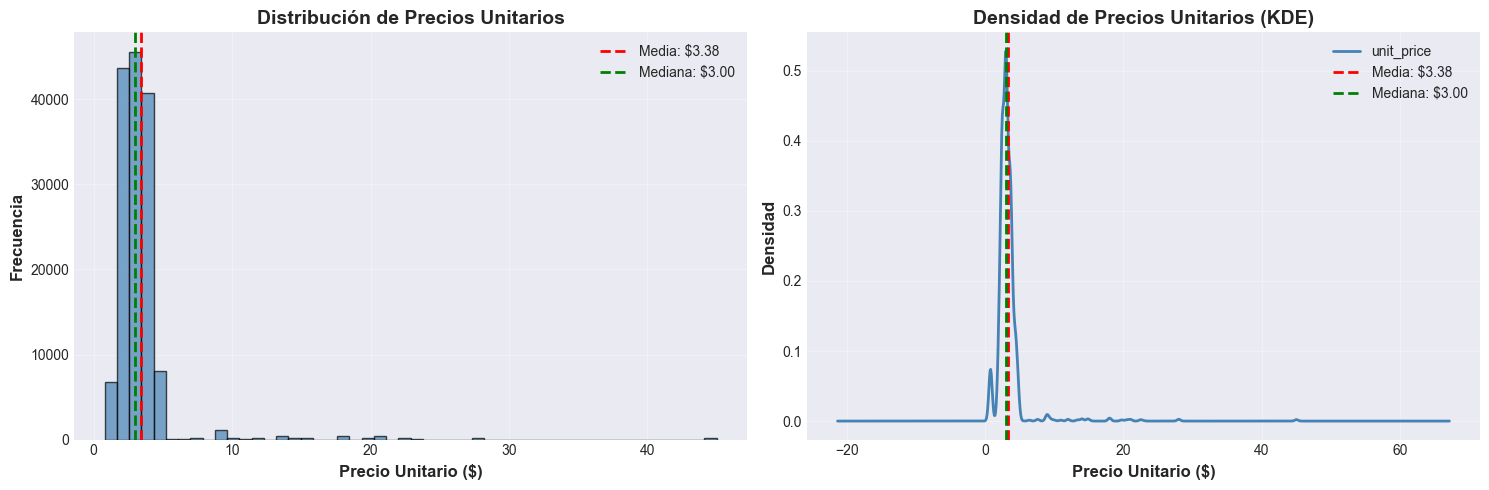

Precio mínimo: $0.80
Precio máximo: $45.00
Rango de precios: $44.20
Desviación estándar: $2.66


In [19]:
# Distribución de unit_price (histograma + KDE)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
axes[0].hist(df['unit_price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['unit_price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["unit_price"].mean():.2f}')
axes[0].axvline(df['unit_price'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${df["unit_price"].median():.2f}')
axes[0].set_xlabel('Precio Unitario ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Precios Unitarios', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# KDE (Kernel Density Estimation)
df['unit_price'].plot(kind='kde', ax=axes[1], color='steelblue', linewidth=2)
axes[1].axvline(df['unit_price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["unit_price"].mean():.2f}')
axes[1].axvline(df['unit_price'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${df["unit_price"].median():.2f}')
axes[1].set_xlabel('Precio Unitario ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Densidad', fontsize=12, fontweight='bold')
axes[1].set_title('Densidad de Precios Unitarios (KDE)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Precio mínimo: ${df['unit_price'].min():.2f}")
print(f"Precio máximo: ${df['unit_price'].max():.2f}")
print(f"Rango de precios: ${df['unit_price'].max() - df['unit_price'].min():.2f}")
print(f"Desviación estándar: ${df['unit_price'].std():.2f}")


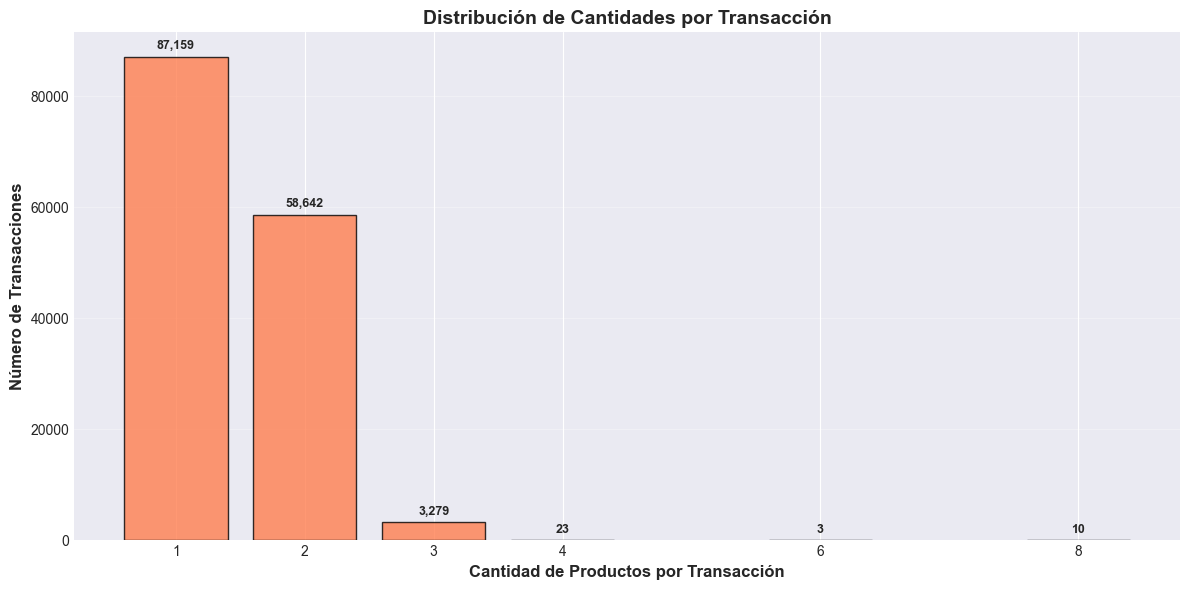


Cantidad más común: 1 productos
Cantidad promedio: 1.44 productos
Cantidad mediana: 1 productos


In [20]:
# Distribución de transaction_qty (gráfico de barras)
qty_counts = df['transaction_qty'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(qty_counts.index, qty_counts.values, edgecolor='black', alpha=0.8, color='coral')
plt.xlabel('Cantidad de Productos por Transacción', fontsize=12, fontweight='bold')
plt.ylabel('Número de Transacciones', fontsize=12, fontweight='bold')
plt.title('Distribución de Cantidades por Transacción', fontsize=14, fontweight='bold')
plt.xticks(qty_counts.index)
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, v in enumerate(qty_counts.values):
    plt.text(qty_counts.index[i], v + max(qty_counts.values)*0.01, f'{v:,}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nCantidad más común: {df['transaction_qty'].mode()[0]} productos")
print(f"Cantidad promedio: {df['transaction_qty'].mean():.2f} productos")
print(f"Cantidad mediana: {df['transaction_qty'].median():.0f} productos")


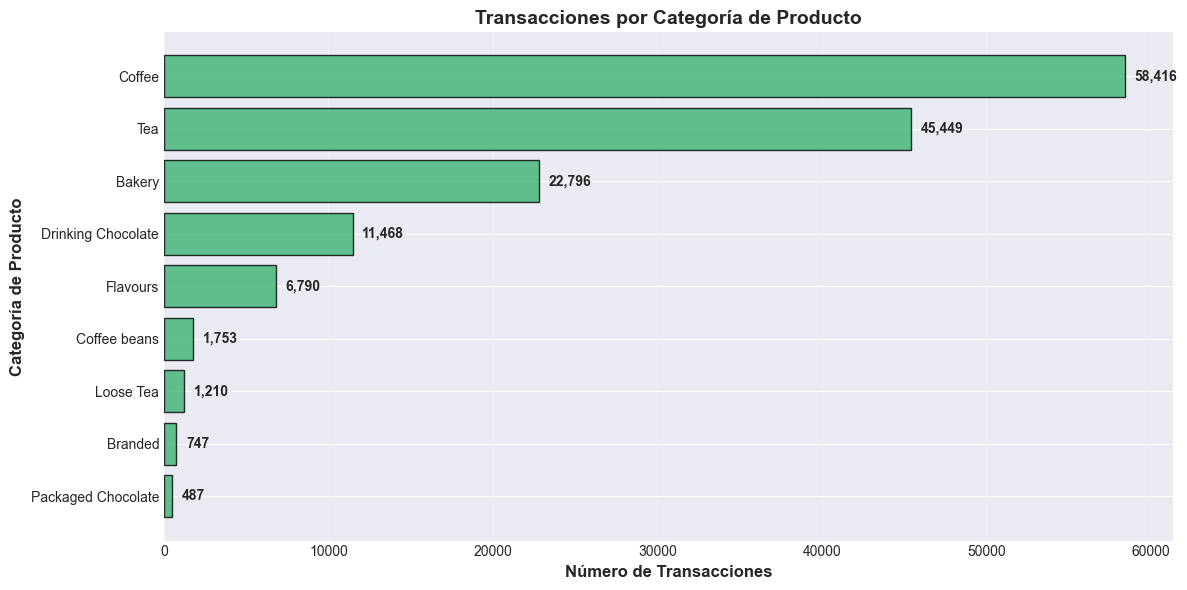


Distribución porcentual por categoría:
product_category
Coffee               39.17
Tea                  30.48
Bakery               15.29
Drinking Chocolate    7.69
Flavours              4.55
Coffee beans          1.18
Loose Tea             0.81
Branded               0.50
Packaged Chocolate    0.33
Name: count, dtype: float64


In [21]:
# Transacciones por product_category (gráfico de barras horizontal)
category_counts = df['product_category'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(category_counts.index, category_counts.values, edgecolor='black', alpha=0.8, color='mediumseagreen')
plt.xlabel('Número de Transacciones', fontsize=12, fontweight='bold')
plt.ylabel('Categoría de Producto', fontsize=12, fontweight='bold')
plt.title('Transacciones por Categoría de Producto', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Añadir valores al final de las barras
for i, v in enumerate(category_counts.values):
    plt.text(v + max(category_counts.values)*0.01, i, f'{v:,}', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDistribución porcentual por categoría:")
print((df['product_category'].value_counts() / len(df) * 100).round(2))


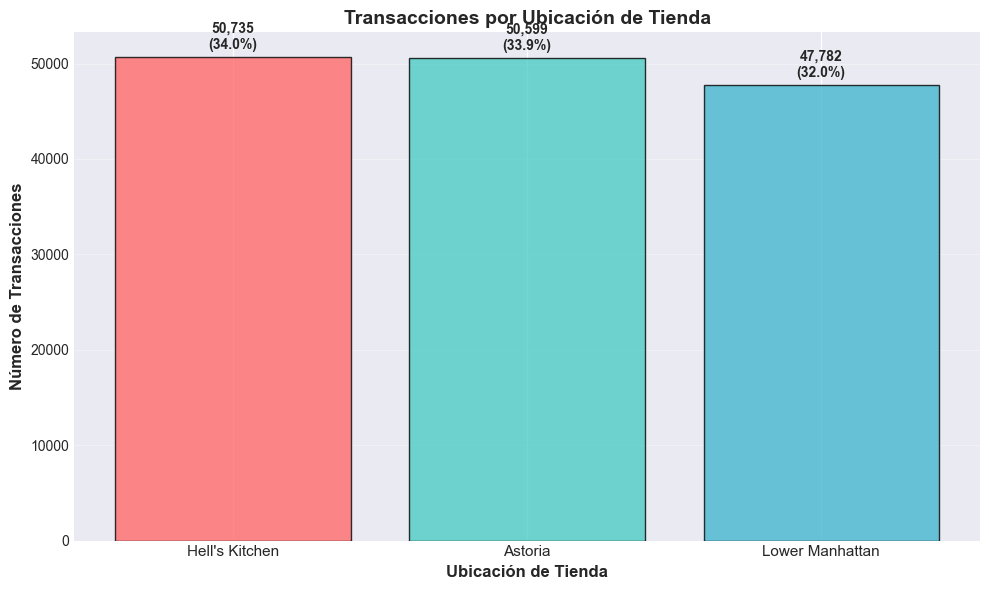


Resumen de transacciones por tienda:
Hell's Kitchen: 50,735 transacciones (34.02%)
Astoria: 50,599 transacciones (33.93%)
Lower Manhattan: 47,782 transacciones (32.04%)


In [22]:
# Transacciones por store_location (gráfico de barras)
store_counts = df['store_location'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(store_counts.index, store_counts.values, edgecolor='black', alpha=0.8, color=colors[:len(store_counts)])
plt.xlabel('Ubicación de Tienda', fontsize=12, fontweight='bold')
plt.ylabel('Número de Transacciones', fontsize=12, fontweight='bold')
plt.title('Transacciones por Ubicación de Tienda', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, (idx, v) in enumerate(store_counts.items()):
    plt.text(i, v + max(store_counts.values)*0.01, f'{v:,}\n({v/len(df)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nResumen de transacciones por tienda:")
for tienda, count in store_counts.items():
    print(f"{tienda}: {count:,} transacciones ({count/len(df)*100:.2f}%)")


## 4. Análisis de Series Temporales

Exploración de patrones temporales en ingresos y transacciones: tendencias diarias, mensuales, por día de semana, hora del día y combinaciones.

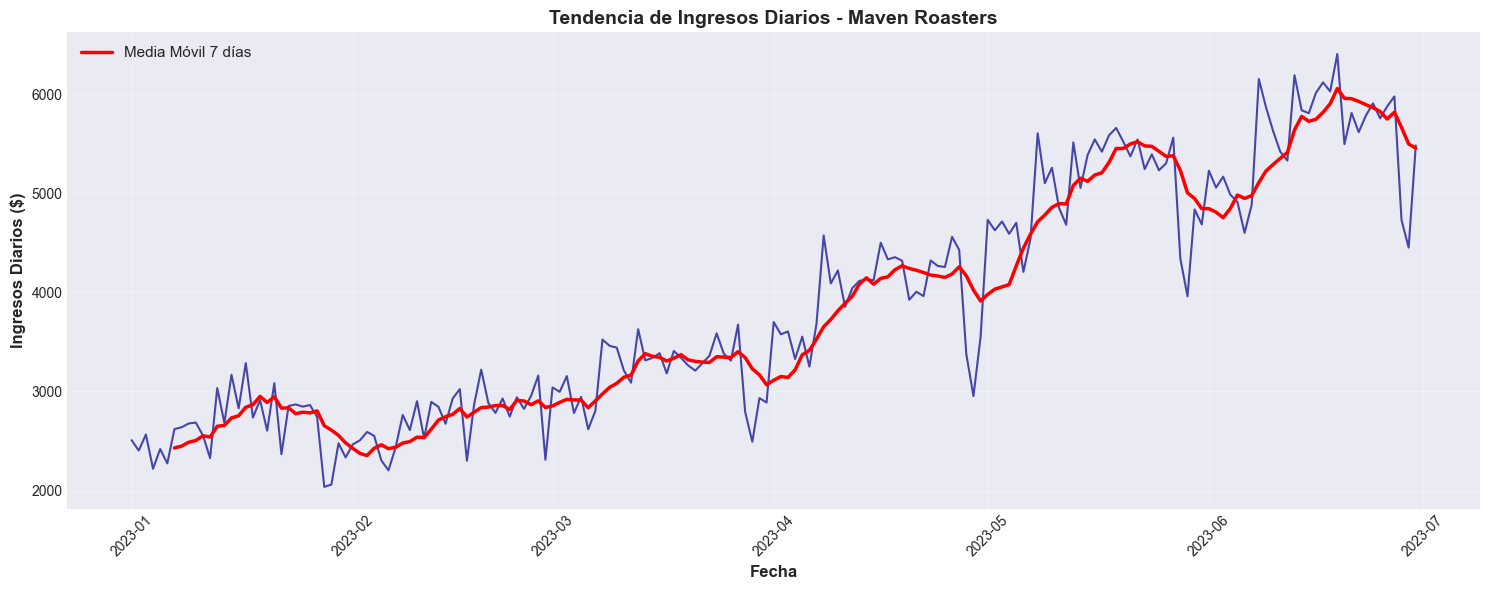

Ingresos diarios promedio: $3,860.84
Día con mayores ingresos: 2023-06-19 ($6,403.91)
Día con menores ingresos: 2023-01-28 ($2,037.10)


In [23]:
# Tendencia de ingresos diarios (gráfico de línea)
revenue_daily = df.groupby('transaction_date')['revenue'].sum().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(revenue_daily['transaction_date'], revenue_daily['revenue'], 
         color='darkblue', linewidth=1.5, alpha=0.7)
plt.plot(revenue_daily['transaction_date'], revenue_daily['revenue'].rolling(window=7).mean(), 
         color='red', linewidth=2.5, label='Media Móvil 7 días')
plt.xlabel('Fecha', fontsize=12, fontweight='bold')
plt.ylabel('Ingresos Diarios ($)', fontsize=12, fontweight='bold')
plt.title('Tendencia de Ingresos Diarios - Maven Roasters', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Ingresos diarios promedio: ${revenue_daily['revenue'].mean():,.2f}")
print(f"Día con mayores ingresos: {revenue_daily.loc[revenue_daily['revenue'].idxmax(), 'transaction_date'].strftime('%Y-%m-%d')} (${revenue_daily['revenue'].max():,.2f})")
print(f"Día con menores ingresos: {revenue_daily.loc[revenue_daily['revenue'].idxmin(), 'transaction_date'].strftime('%Y-%m-%d')} (${revenue_daily['revenue'].min():,.2f})")


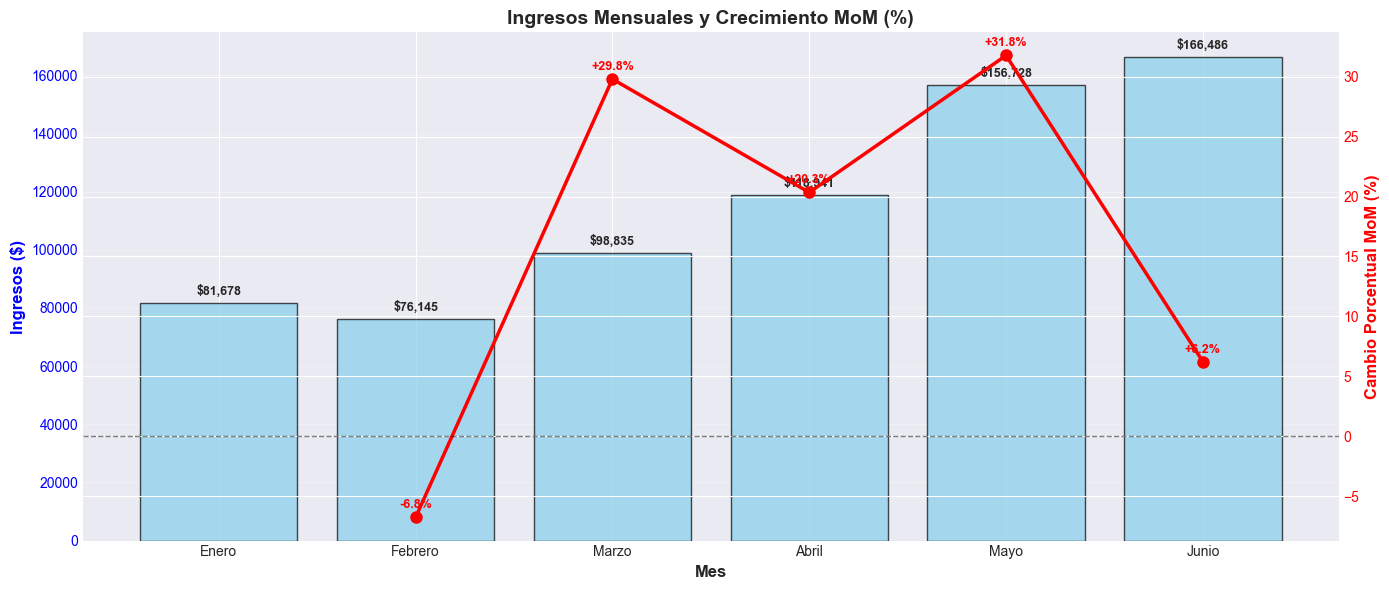


Resumen de ingresos mensuales:
Enero: $81,677.74
Febrero: $76,145.19 (-6.77% vs mes anterior)
Marzo: $98,834.68 (+29.80% vs mes anterior)
Abril: $118,941.08 (+20.34% vs mes anterior)
Mayo: $156,727.76 (+31.77% vs mes anterior)
Junio: $166,485.88 (+6.23% vs mes anterior)


In [24]:
# Ingresos mensuales con cálculo de cambio porcentual MoM
revenue_monthly = df.groupby('month_name')['revenue'].sum().reset_index()

# Calcular cambio porcentual mes a mes
revenue_monthly['pct_change'] = revenue_monthly['revenue'].pct_change() * 100

# Gráfico de barras con cambio porcentual
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras de ingresos
x_pos = range(len(revenue_monthly))
bars = ax1.bar(x_pos, revenue_monthly['revenue'], edgecolor='black', alpha=0.7, color='skyblue')
ax1.set_xlabel('Mes', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ingresos ($)', fontsize=12, fontweight='bold', color='blue')
ax1.set_title('Ingresos Mensuales y Crecimiento MoM (%)', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(revenue_monthly['month_name'], rotation=0)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, v in enumerate(revenue_monthly['revenue']):
    ax1.text(i, v + max(revenue_monthly['revenue'])*0.01, f'${v:,.0f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Línea de cambio porcentual
ax2 = ax1.twinx()
ax2.plot(x_pos[1:], revenue_monthly['pct_change'][1:], color='red', marker='o', 
         linewidth=2.5, markersize=8, label='Cambio MoM (%)')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_ylabel('Cambio Porcentual MoM (%)', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Añadir valores de porcentaje
for i, v in enumerate(revenue_monthly['pct_change'][1:], 1):
    ax2.text(i, v + 0.5, f'{v:+.1f}%', ha='center', va='bottom', 
             fontsize=9, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

print("\nResumen de ingresos mensuales:")
for idx, row in revenue_monthly.iterrows():
    if pd.isna(row['pct_change']):
        print(f"{row['month_name']}: ${row['revenue']:,.2f}")
    else:
        print(f"{row['month_name']}: ${row['revenue']:,.2f} ({row['pct_change']:+.2f}% vs mes anterior)")


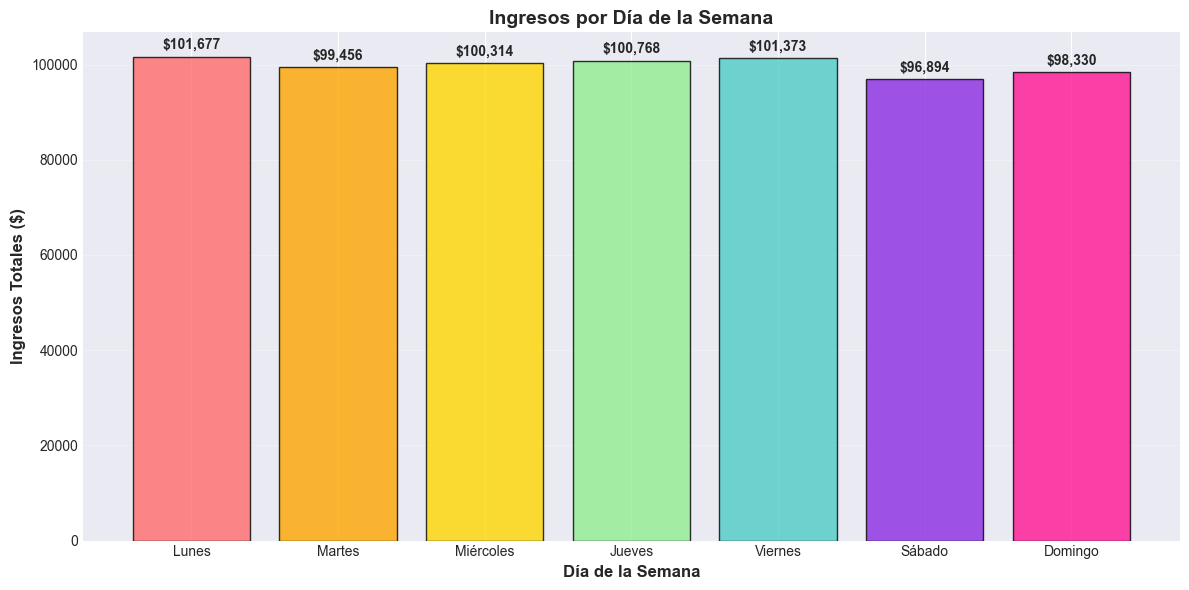


Día con mayores ingresos: Lunes
Día con menores ingresos: Sábado

Diferencia entre mejor y peor día: $4,782.80


In [25]:
# Ingresos por día de la semana (ordenado Lunes-Domingo)
revenue_by_day = df.groupby('day_name')['revenue'].sum().reset_index()

plt.figure(figsize=(12, 6))
colors_dias = ['#FF6B6B', '#FFA500', '#FFD700', '#90EE90', '#4ECDC4', '#8A2BE2', '#FF1493']
bars = plt.bar(revenue_by_day['day_name'], revenue_by_day['revenue'], 
               edgecolor='black', alpha=0.8, color=colors_dias)
plt.xlabel('Día de la Semana', fontsize=12, fontweight='bold')
plt.ylabel('Ingresos Totales ($)', fontsize=12, fontweight='bold')
plt.title('Ingresos por Día de la Semana', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, v in enumerate(revenue_by_day['revenue']):
    plt.text(i, v + max(revenue_by_day['revenue'])*0.01, f'${v:,.0f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDía con mayores ingresos:", revenue_by_day.loc[revenue_by_day['revenue'].idxmax(), 'day_name'])
print("Día con menores ingresos:", revenue_by_day.loc[revenue_by_day['revenue'].idxmin(), 'day_name'])
print(f"\nDiferencia entre mejor y peor día: ${revenue_by_day['revenue'].max() - revenue_by_day['revenue'].min():,.2f}")


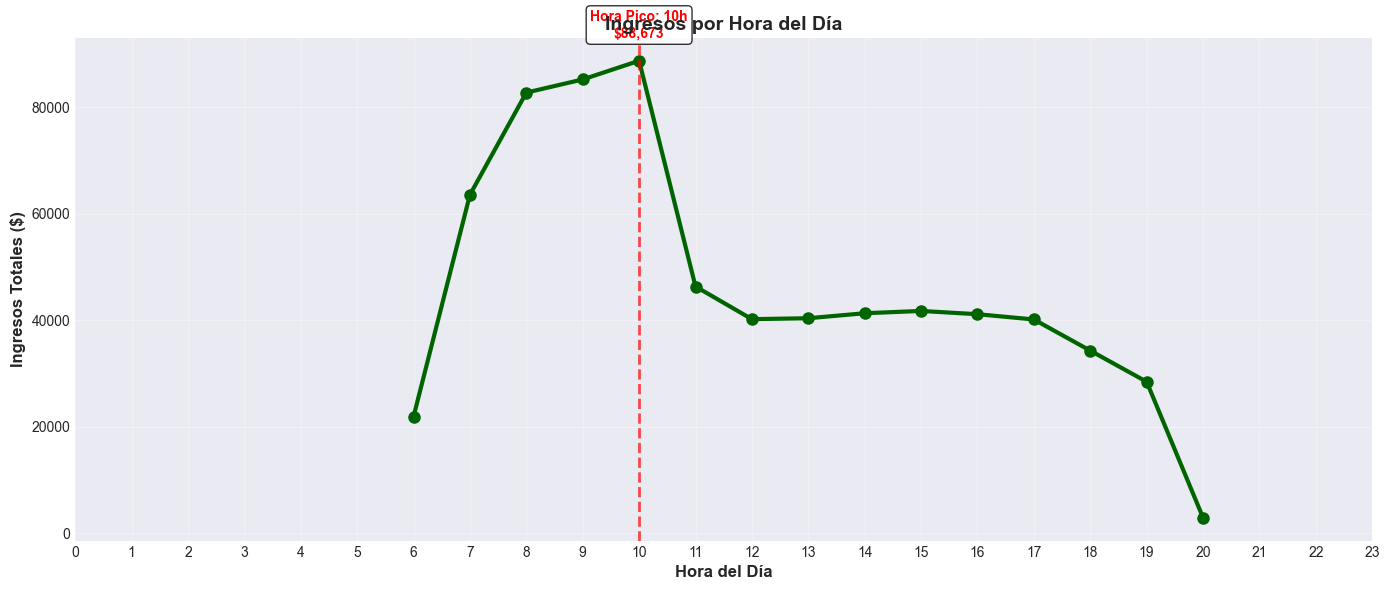

Hora pico de ingresos: 10:00 hrs ($88,673.39)
Hora con menores ingresos: 20:00 hrs ($2,935.64)


In [26]:
# Ingresos por hora del día (gráfico de línea)
revenue_by_hour = df.groupby('hour')['revenue'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(revenue_by_hour['hour'], revenue_by_hour['revenue'], 
         color='darkgreen', linewidth=3, marker='o', markersize=8)
plt.xlabel('Hora del Día', fontsize=12, fontweight='bold')
plt.ylabel('Ingresos Totales ($)', fontsize=12, fontweight='bold')
plt.title('Ingresos por Hora del Día', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

# Marcar hora pico
hora_pico = revenue_by_hour.loc[revenue_by_hour['revenue'].idxmax(), 'hour']
ingresos_pico = revenue_by_hour['revenue'].max()
plt.axvline(x=hora_pico, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.text(hora_pico, ingresos_pico * 1.05, f'Hora Pico: {hora_pico}h\n${ingresos_pico:,.0f}', 
         ha='center', fontsize=10, fontweight='bold', color='red',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Hora pico de ingresos: {hora_pico}:00 hrs (${ingresos_pico:,.2f})")
print(f"Hora con menores ingresos: {revenue_by_hour.loc[revenue_by_hour['revenue'].idxmin(), 'hour']}:00 hrs (${revenue_by_hour['revenue'].min():,.2f})")


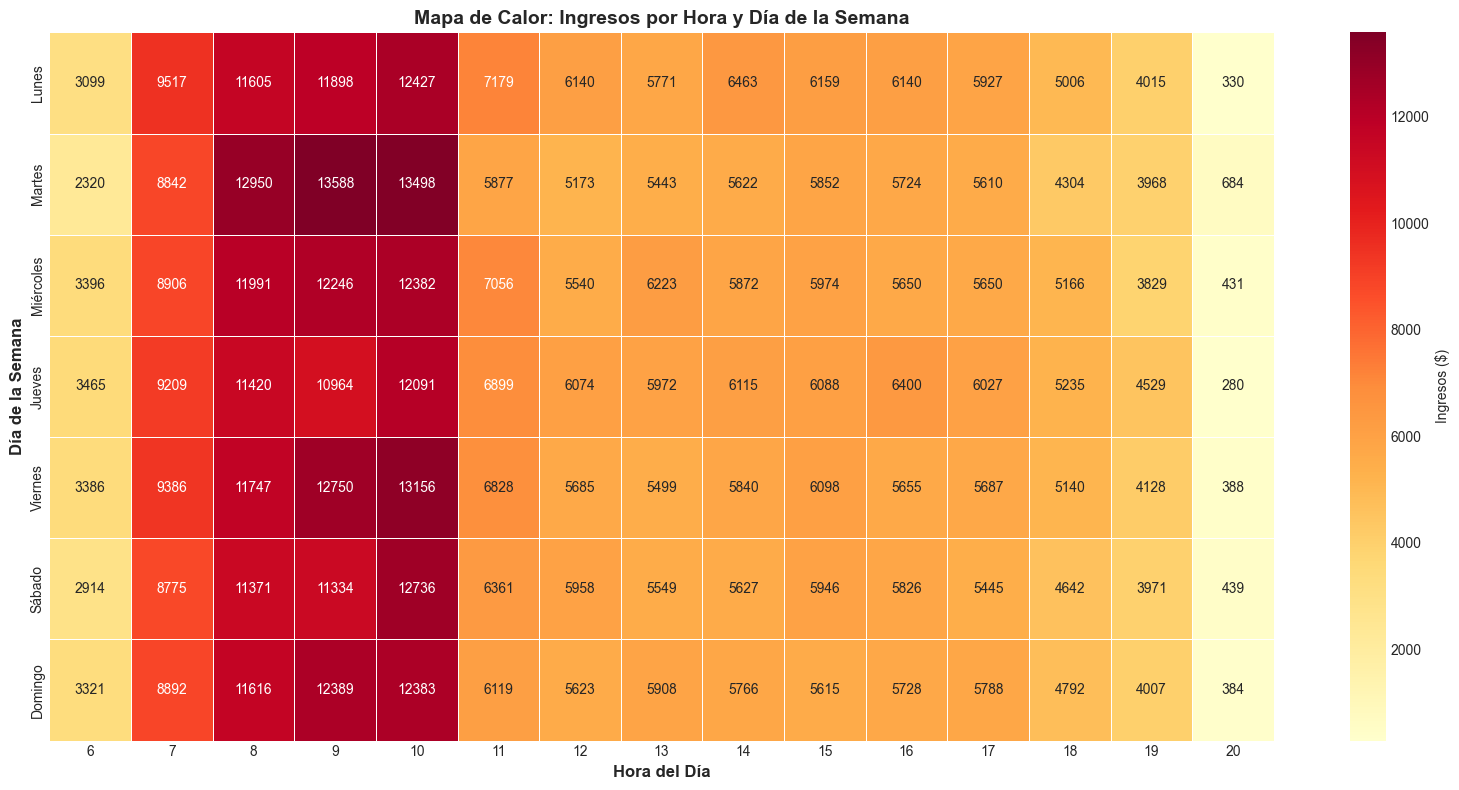


Periodo de mayor actividad: Martes a las 9:00 hrs ($13,588.47)


In [27]:
# Mapa de calor: ingresos por hora × día de la semana
heatmap_data = df.groupby(['day_name', 'hour'])['revenue'].sum().unstack(fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Ingresos ($)'}, linewidths=0.5)
plt.xlabel('Hora del Día', fontsize=12, fontweight='bold')
plt.ylabel('Día de la Semana', fontsize=12, fontweight='bold')
plt.title('Mapa de Calor: Ingresos por Hora y Día de la Semana', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar el periodo de mayor actividad
max_idx = heatmap_data.stack().idxmax()
max_val = heatmap_data.stack().max()
print(f"\nPeriodo de mayor actividad: {max_idx[0]} a las {max_idx[1]}:00 hrs (${max_val:,.2f})")


## 5. Análisis Comparativo entre Tiendas

Comparación de rendimiento entre las tres ubicaciones de Maven Roasters: ingresos, transacciones, ticket promedio, patrones temporales y categorías de productos.

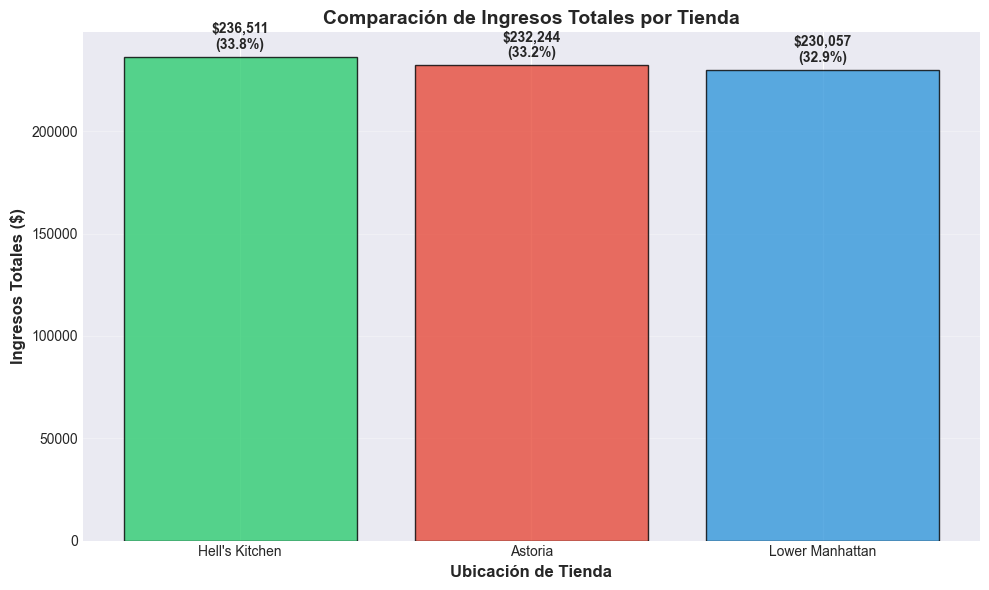

Ranking de tiendas por ingresos:
1. Hell's Kitchen: $236,511.17 (33.84%)
2. Astoria: $232,243.91 (33.23%)
3. Lower Manhattan: $230,057.25 (32.92%)


In [28]:
# Ingresos totales por tienda
revenue_by_store = df.groupby('store_location')['revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
colors = ['#2ECC71', '#E74C3C', '#3498DB']
bars = plt.bar(revenue_by_store['store_location'], revenue_by_store['revenue'], 
               edgecolor='black', alpha=0.8, color=colors[:len(revenue_by_store)])
plt.xlabel('Ubicación de Tienda', fontsize=12, fontweight='bold')
plt.ylabel('Ingresos Totales ($)', fontsize=12, fontweight='bold')
plt.title('Comparación de Ingresos Totales por Tienda', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores y porcentajes sobre las barras
total_revenue = revenue_by_store['revenue'].sum()
for i, (idx, row) in enumerate(revenue_by_store.iterrows()):
    pct = (row['revenue'] / total_revenue) * 100
    plt.text(i, row['revenue'] + max(revenue_by_store['revenue'])*0.01, 
             f"${row['revenue']:,.0f}\n({pct:.1f}%)", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Ranking de tiendas por ingresos:")
for i, row in revenue_by_store.iterrows():
    pct = (row['revenue'] / total_revenue) * 100
    print(f"{i+1}. {row['store_location']}: ${row['revenue']:,.2f} ({pct:.2f}%)")


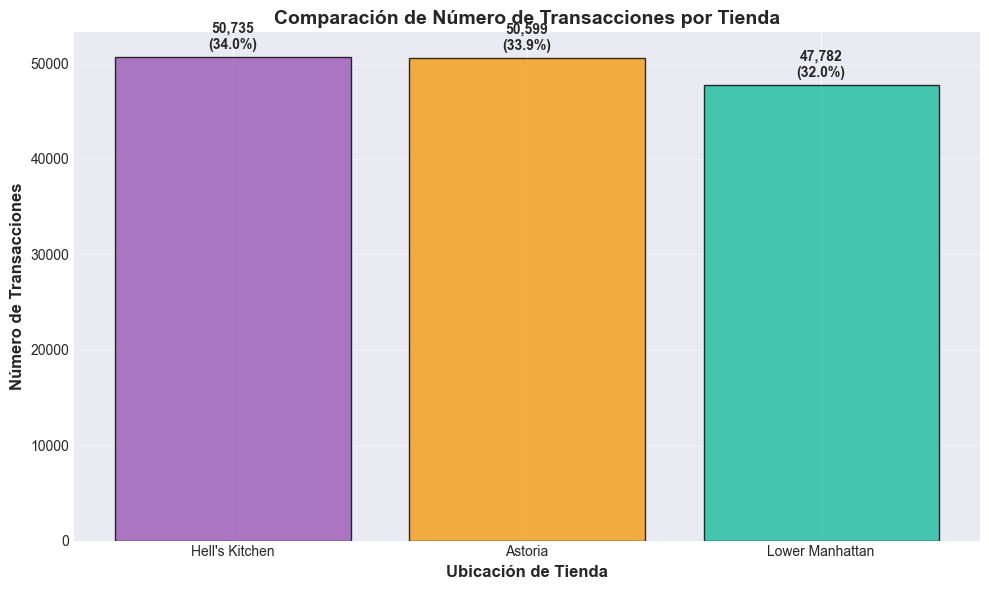

In [29]:
# Número de transacciones por tienda
transactions_by_store = df.groupby('store_location').size().sort_values(ascending=False).reset_index(name='transactions')

plt.figure(figsize=(10, 6))
colors = ['#9B59B6', '#F39C12', '#1ABC9C']
bars = plt.bar(transactions_by_store['store_location'], transactions_by_store['transactions'], 
               edgecolor='black', alpha=0.8, color=colors[:len(transactions_by_store)])
plt.xlabel('Ubicación de Tienda', fontsize=12, fontweight='bold')
plt.ylabel('Número de Transacciones', fontsize=12, fontweight='bold')
plt.title('Comparación de Número de Transacciones por Tienda', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
total_trans = transactions_by_store['transactions'].sum()
for i, (idx, row) in enumerate(transactions_by_store.iterrows()):
    pct = (row['transactions'] / total_trans) * 100
    plt.text(i, row['transactions'] + max(transactions_by_store['transactions'])*0.01, 
             f"{row['transactions']:,}\n({pct:.1f}%)", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


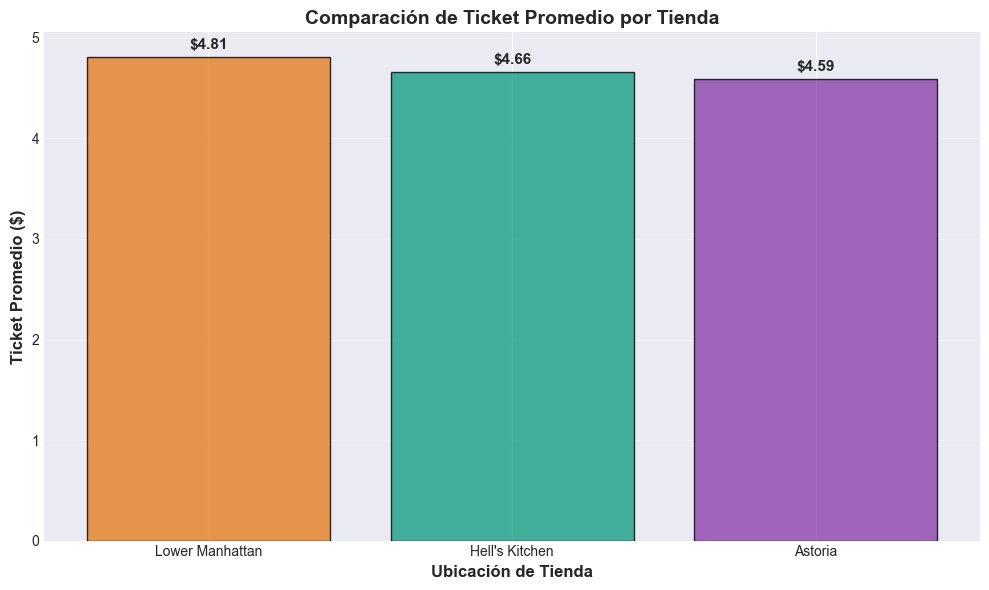


Resumen de ticket promedio por tienda:
Lower Manhattan: $4.81
Hell's Kitchen: $4.66
Astoria: $4.59


In [30]:
# Ticket promedio por tienda
avg_ticket_by_store = df.groupby('store_location')['revenue'].mean().sort_values(ascending=False).reset_index()
avg_ticket_by_store.columns = ['store_location', 'avg_ticket']

plt.figure(figsize=(10, 6))
colors = ['#E67E22', '#16A085', '#8E44AD']
bars = plt.bar(avg_ticket_by_store['store_location'], avg_ticket_by_store['avg_ticket'], 
               edgecolor='black', alpha=0.8, color=colors[:len(avg_ticket_by_store)])
plt.xlabel('Ubicación de Tienda', fontsize=12, fontweight='bold')
plt.ylabel('Ticket Promedio ($)', fontsize=12, fontweight='bold')
plt.title('Comparación de Ticket Promedio por Tienda', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, (idx, row) in enumerate(avg_ticket_by_store.iterrows()):
    plt.text(i, row['avg_ticket'] + max(avg_ticket_by_store['avg_ticket'])*0.01, 
             f"${row['avg_ticket']:.2f}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nResumen de ticket promedio por tienda:")
for idx, row in avg_ticket_by_store.iterrows():
    print(f"{row['store_location']}: ${row['avg_ticket']:.2f}")


In [31]:
# Ingresos por tienda y mes (gráfico de barras agrupadas)
revenue_store_month = df.groupby(['store_location', 'month_name'])['revenue'].sum().reset_index()

fig = px.bar(revenue_store_month, 
             x='month_name', 
             y='revenue', 
             color='store_location',
             barmode='group',
             title='Ingresos Mensuales por Tienda',
             labels={'month_name': 'Mes', 'revenue': 'Ingresos ($)', 'store_location': 'Tienda'},
             color_discrete_sequence=['#FF6B6B', '#4ECDC4', '#45B7D1'])

fig.update_layout(font=dict(size=12), title_font_size=16, height=500)
fig.show()

# Identificar mes y tienda con mayores ingresos
max_idx = revenue_store_month['revenue'].idxmax()
max_row = revenue_store_month.loc[max_idx]
print(f"\nMejor combinación mes-tienda: {max_row['store_location']} en {max_row['month_name']} (${max_row['revenue']:,.2f})")



Mejor combinación mes-tienda: Hell's Kitchen en Junio ($56,957.08)


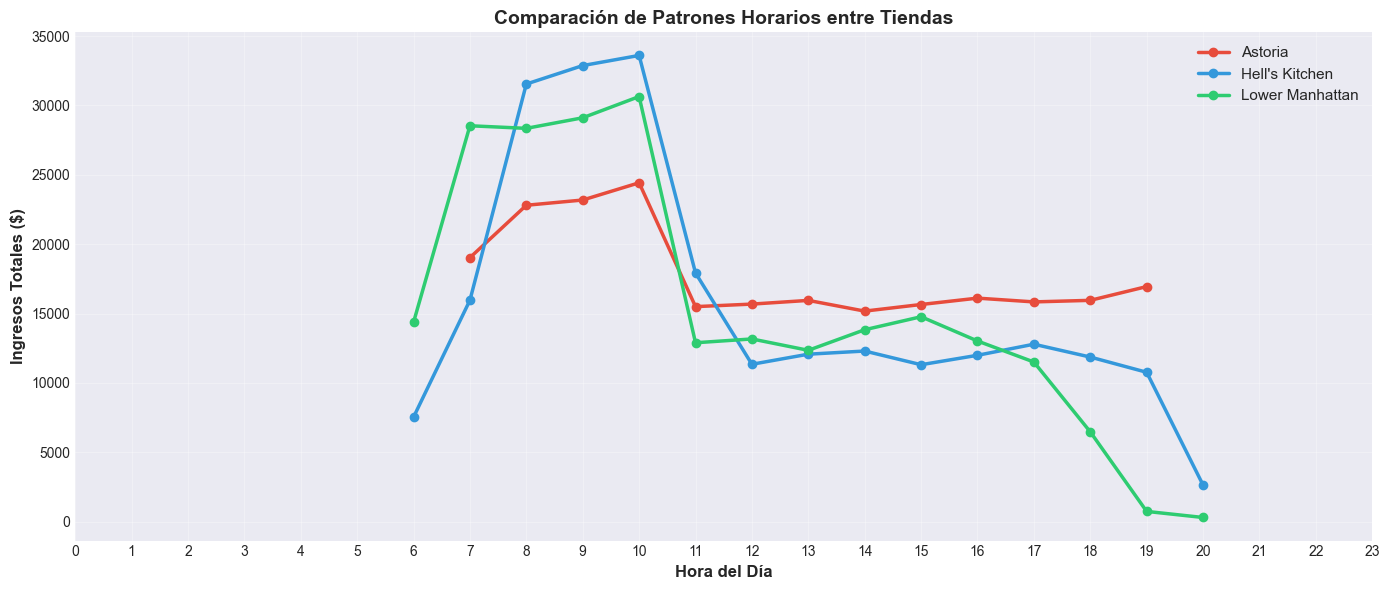


Hora pico por tienda:
Astoria: 10:00 hrs ($24,426.12)
Hell's Kitchen: 10:00 hrs ($33,605.81)
Lower Manhattan: 10:00 hrs ($30,641.46)


In [32]:
# Comparación de horas pico entre tiendas (líneas superpuestas)
revenue_store_hour = df.groupby(['store_location', 'hour'])['revenue'].sum().reset_index()

plt.figure(figsize=(14, 6))
stores = revenue_store_hour['store_location'].unique()
colors_stores = ['#E74C3C', '#3498DB', '#2ECC71']

for i, store in enumerate(stores):
    store_data = revenue_store_hour[revenue_store_hour['store_location'] == store]
    plt.plot(store_data['hour'], store_data['revenue'], 
             marker='o', linewidth=2.5, markersize=6, label=store, color=colors_stores[i])

plt.xlabel('Hora del Día', fontsize=12, fontweight='bold')
plt.ylabel('Ingresos Totales ($)', fontsize=12, fontweight='bold')
plt.title('Comparación de Patrones Horarios entre Tiendas', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar hora pico por tienda
print("\nHora pico por tienda:")
for store in stores:
    store_data = revenue_store_hour[revenue_store_hour['store_location'] == store]
    hora_pico = store_data.loc[store_data['revenue'].idxmax(), 'hour']
    ingresos_pico = store_data['revenue'].max()
    print(f"{store}: {hora_pico}:00 hrs (${ingresos_pico:,.2f})")


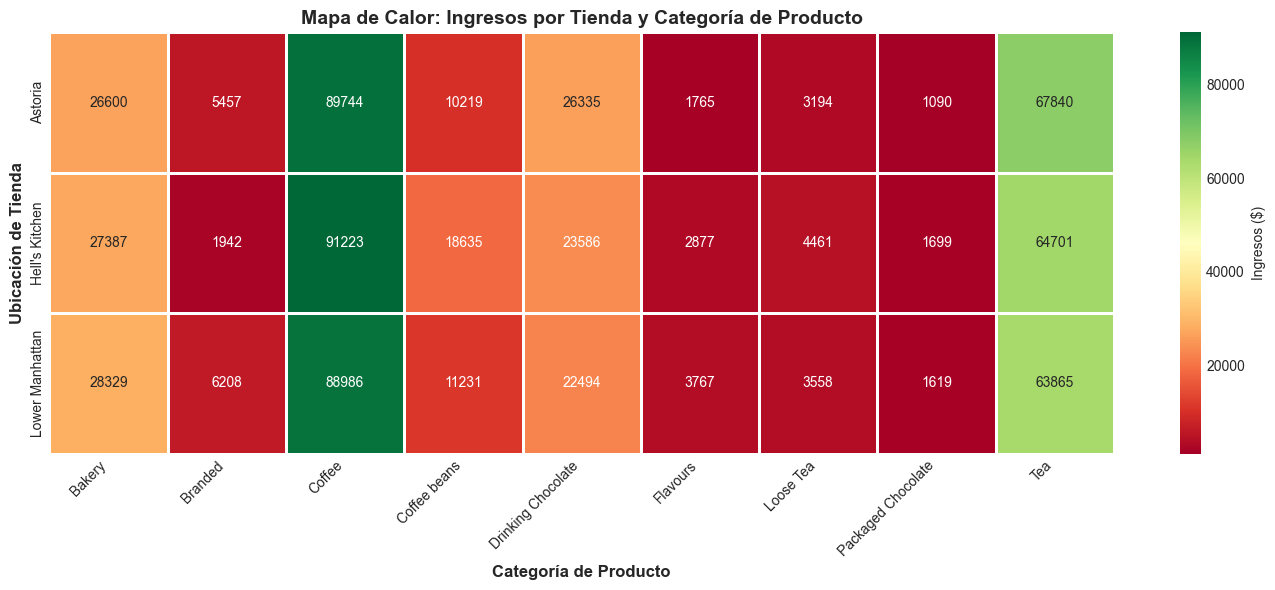


Mejor combinación tienda-categoría: Hell's Kitchen - Coffee ($91,222.65)


In [33]:
# Mapa de calor: ingresos por tienda × categoría de producto
heatmap_store_category = df.groupby(['store_location', 'product_category'])['revenue'].sum().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_store_category, annot=True, fmt='.0f', cmap='RdYlGn', 
            cbar_kws={'label': 'Ingresos ($)'}, linewidths=1)
plt.xlabel('Categoría de Producto', fontsize=12, fontweight='bold')
plt.ylabel('Ubicación de Tienda', fontsize=12, fontweight='bold')
plt.title('Mapa de Calor: Ingresos por Tienda y Categoría de Producto', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Identificar combinación de mayor rendimiento
max_idx = heatmap_store_category.stack().idxmax()
max_val = heatmap_store_category.stack().max()
print(f"\nMejor combinación tienda-categoría: {max_idx[0]} - {max_idx[1]} (${max_val:,.2f})")


## 6. Análisis de Productos y Categorías

Identificación de productos y categorías de mayor y menor rendimiento, participación de mercado y evolución temporal.

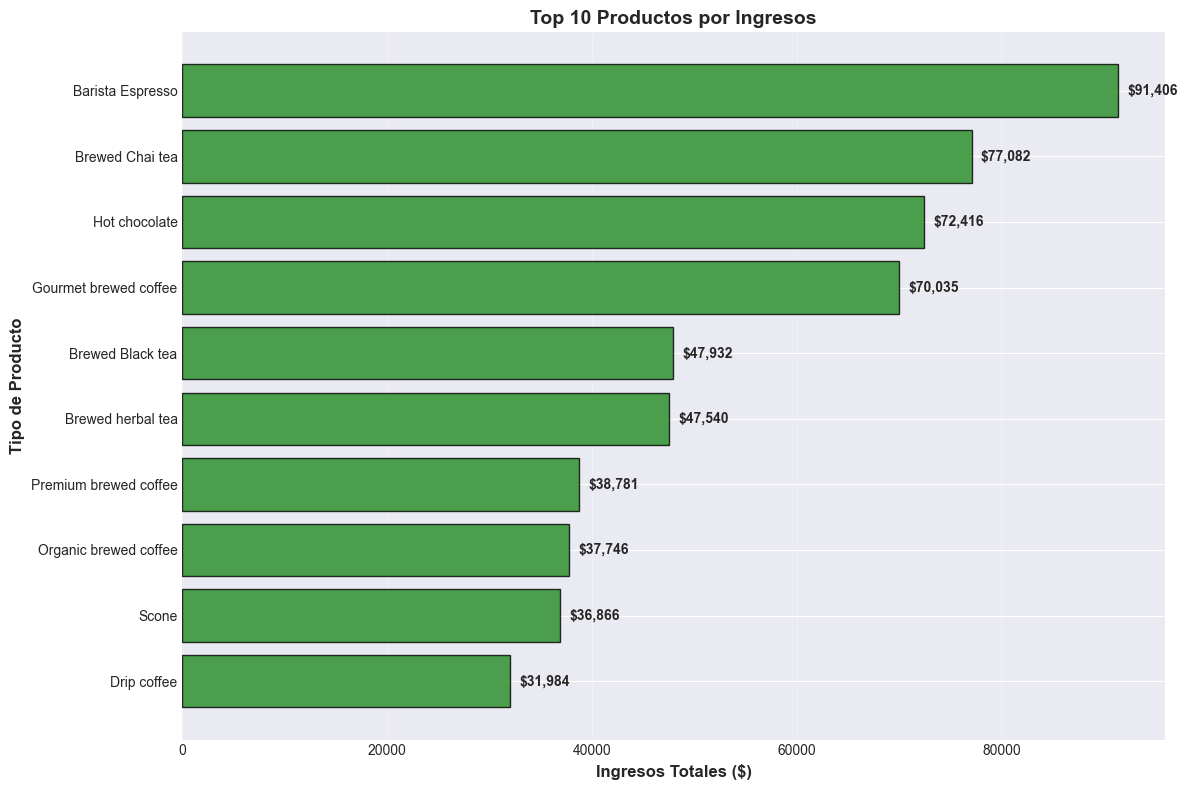


Top 10 productos:
1. Barista Espresso: $91,406.20
2. Brewed Chai tea: $77,081.95
3. Hot chocolate: $72,416.00
4. Gourmet brewed coffee: $70,034.60
5. Brewed Black tea: $47,932.00
6. Brewed herbal tea: $47,539.50
7. Premium brewed coffee: $38,781.15
8. Organic brewed coffee: $37,746.50
9. Scone: $36,866.12
10. Drip coffee: $31,984.00


In [34]:
# Top 10 product_type por ingresos (gráfico horizontal)
top10_products = df.groupby('product_type')['revenue'].sum().nlargest(10).sort_values(ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top10_products)), top10_products.values, 
         edgecolor='black', alpha=0.8, color='forestgreen')
plt.yticks(range(len(top10_products)), top10_products.index)
plt.xlabel('Ingresos Totales ($)', fontsize=12, fontweight='bold')
plt.ylabel('Tipo de Producto', fontsize=12, fontweight='bold')
plt.title('Top 10 Productos por Ingresos', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Añadir valores al final de las barras
for i, v in enumerate(top10_products.values):
    plt.text(v + max(top10_products.values)*0.01, i, f'${v:,.0f}', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 10 productos:")
for i, (prod, rev) in enumerate(top10_products[::-1].items(), 1):
    print(f"{i}. {prod}: ${rev:,.2f}")


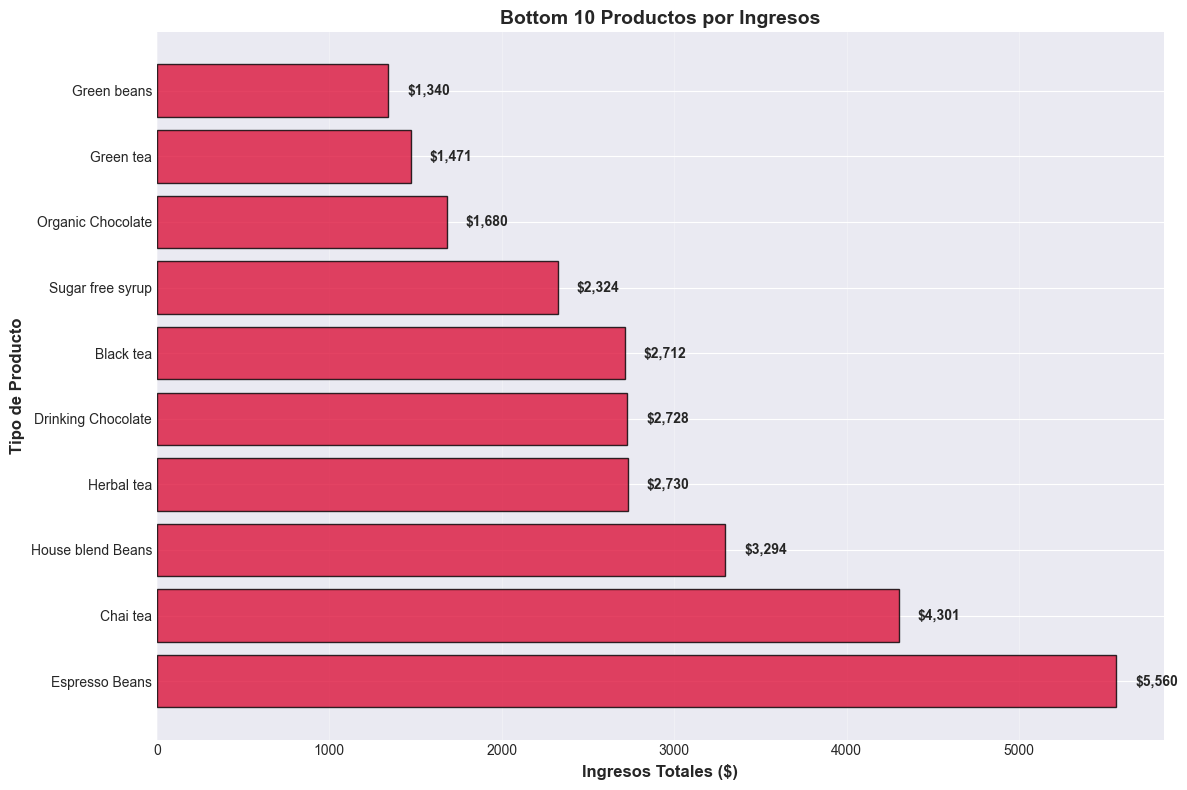


Bottom 10 productos (menor a mayor):
1. Green beans: $1,340.00
2. Green tea: $1,470.75
3. Organic Chocolate: $1,679.60
4. Sugar free syrup: $2,324.00
5. Black tea: $2,711.85
6. Drinking Chocolate: $2,728.04
7. Herbal tea: $2,729.75
8. House blend Beans: $3,294.00
9. Chai tea: $4,301.25
10. Espresso Beans: $5,560.25


In [35]:
# Bottom 10 product_type por ingresos (gráfico horizontal)
bottom10_products = df.groupby('product_type')['revenue'].sum().nsmallest(10).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(range(len(bottom10_products)), bottom10_products.values, 
         edgecolor='black', alpha=0.8, color='crimson')
plt.yticks(range(len(bottom10_products)), bottom10_products.index)
plt.xlabel('Ingresos Totales ($)', fontsize=12, fontweight='bold')
plt.ylabel('Tipo de Producto', fontsize=12, fontweight='bold')
plt.title('Bottom 10 Productos por Ingresos', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Añadir valores al final de las barras
for i, v in enumerate(bottom10_products.values):
    plt.text(v + max(bottom10_products.values)*0.02, i, f'${v:,.0f}', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nBottom 10 productos (menor a mayor):")
for i, (prod, rev) in enumerate(bottom10_products[::-1].items(), 1):
    print(f"{i}. {prod}: ${rev:,.2f}")


In [36]:
# Participación de ingresos por categoría (gráfico de dona)
revenue_by_category = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

fig = go.Figure(data=[go.Pie(
    labels=revenue_by_category.index,
    values=revenue_by_category.values,
    hole=0.4,
    marker=dict(colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']),
    textinfo='label+percent',
    textfont_size=12,
    hovertemplate='<b>%{label}</b><br>Ingresos: $%{value:,.0f}<br>Porcentaje: %{percent}<extra></extra>'
)])

fig.update_layout(
    title={
        'text': 'Participación de Ingresos por Categoría de Producto',
        'font': {'size': 16, 'family': 'Arial, sans-serif', 'color': 'black'}
    },
    height=500,
    showlegend=True
)

fig.show()

print("\nDistribución de ingresos por categoría:")
total_cat_revenue = revenue_by_category.sum()
for cat, rev in revenue_by_category.items():
    pct = (rev / total_cat_revenue) * 100
    print(f"{cat}: ${rev:,.2f} ({pct:.2f}%)")



Distribución de ingresos por categoría:
Coffee: $269,952.45 (38.63%)
Tea: $196,405.95 (28.11%)
Bakery: $82,315.64 (11.78%)
Drinking Chocolate: $72,416.00 (10.36%)
Coffee beans: $40,085.25 (5.74%)
Branded: $13,607.00 (1.95%)
Loose Tea: $11,213.60 (1.60%)
Flavours: $8,408.80 (1.20%)
Packaged Chocolate: $4,407.64 (0.63%)


In [37]:
# Ingresos por categoría y tienda (gráfico de barras apiladas)
revenue_cat_store = df.groupby(['product_category', 'store_location'])['revenue'].sum().reset_index()

fig = px.bar(revenue_cat_store, 
             x='product_category', 
             y='revenue', 
             color='store_location',
             title='Ingresos por Categoría de Producto y Tienda',
             labels={'product_category': 'Categoría', 'revenue': 'Ingresos ($)', 'store_location': 'Tienda'},
             color_discrete_sequence=['#E74C3C', '#3498DB', '#2ECC71'],
             barmode='stack')

fig.update_layout(font=dict(size=12), title_font_size=16, height=500, xaxis_tickangle=-45)
fig.show()


In [38]:
# Crecimiento MoM de ingresos por categoría (gráfico de líneas)
revenue_cat_month = df.groupby(['month_name', 'product_category'])['revenue'].sum().reset_index()

fig = px.line(revenue_cat_month, 
              x='month_name', 
              y='revenue', 
              color='product_category',
              markers=True,
              title='Evolución Mensual de Ingresos por Categoría',
              labels={'month_name': 'Mes', 'revenue': 'Ingresos ($)', 'product_category': 'Categoría'})

fig.update_layout(font=dict(size=12), title_font_size=16, height=500)
fig.update_traces(line=dict(width=3), marker=dict(size=8))
fig.show()

# Calcular tasa de crecimiento por categoría (Enero vs Junio)
print("\nCrecimiento de ingresos por categoría (Enero → Junio):")
for categoria in df['product_category'].unique():
    cat_data = revenue_cat_month[revenue_cat_month['product_category'] == categoria]
    if len(cat_data) >= 2:
        enero = cat_data[cat_data['month_name'] == 'Enero']['revenue'].values
        junio = cat_data[cat_data['month_name'] == 'Junio']['revenue'].values
        if len(enero) > 0 and len(junio) > 0:
            crecimiento = ((junio[0] - enero[0]) / enero[0]) * 100
            print(f"{categoria}: {crecimiento:+.2f}% (${enero[0]:,.0f} → ${junio[0]:,.0f})")



Crecimiento de ingresos por categoría (Enero → Junio):
Coffee: +107.28% ($31,257 → $64,789)
Tea: +104.42% ($22,622 → $46,243)
Drinking Chocolate: +105.16% ($8,338 → $17,106)
Bakery: +101.89% ($9,536 → $19,251)
Flavours: +106.08% ($974 → $2,008)
Loose Tea: +114.14% ($1,294 → $2,771)
Coffee beans: +88.98% ($5,245 → $9,913)
Packaged Chocolate: +90.09% ($522 → $992)
Branded: +80.58% ($1,890 → $3,413)


## 7. Análisis de Comportamiento Transaccional

Estudio de patrones de compra: cantidad promedio por transacción, distribución de tickets, segmentación de clientes de alto valor.

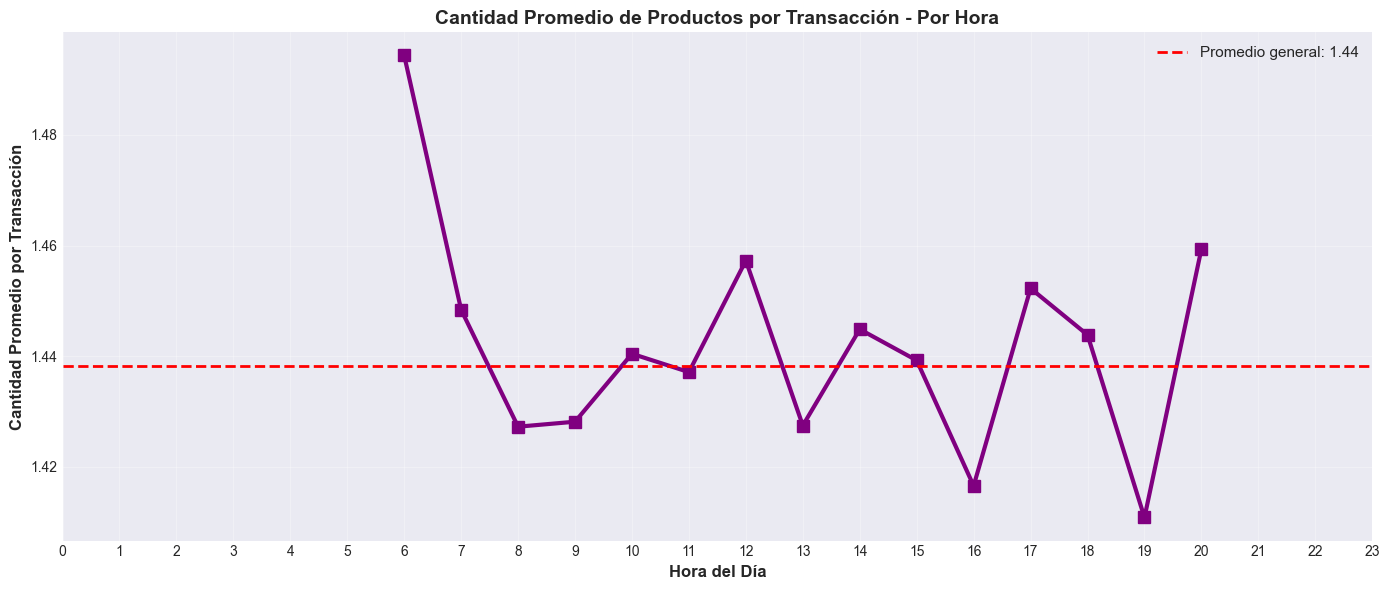

Cantidad promedio general: 1.44 productos por transacción


In [39]:
# Cantidad promedio de productos por transacción, por hora
avg_qty_by_hour = df.groupby('hour')['transaction_qty'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(avg_qty_by_hour['hour'], avg_qty_by_hour['transaction_qty'], 
         color='purple', linewidth=3, marker='s', markersize=8)
plt.xlabel('Hora del Día', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad Promedio por Transacción', fontsize=12, fontweight='bold')
plt.title('Cantidad Promedio de Productos por Transacción - Por Hora', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.axhline(y=df['transaction_qty'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Promedio general: {df["transaction_qty"].mean():.2f}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Cantidad promedio general: {df['transaction_qty'].mean():.2f} productos por transacción")


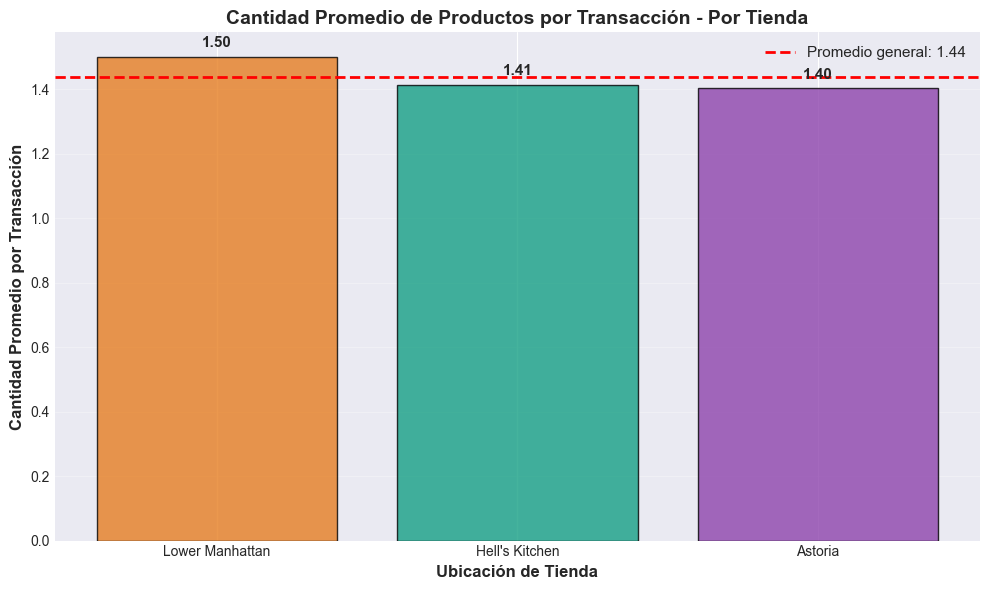


Cantidad promedio por tienda:
Lower Manhattan: 1.50 productos
Hell's Kitchen: 1.41 productos
Astoria: 1.40 productos


In [40]:
# Cantidad promedio de productos por transacción, por tienda
avg_qty_by_store = df.groupby('store_location')['transaction_qty'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
colors = ['#E67E22', '#16A085', '#8E44AD']
bars = plt.bar(avg_qty_by_store['store_location'], avg_qty_by_store['transaction_qty'], 
               edgecolor='black', alpha=0.8, color=colors[:len(avg_qty_by_store)])
plt.xlabel('Ubicación de Tienda', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad Promedio por Transacción', fontsize=12, fontweight='bold')
plt.title('Cantidad Promedio de Productos por Transacción - Por Tienda', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.axhline(y=df['transaction_qty'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Promedio general: {df["transaction_qty"].mean():.2f}')

# Añadir valores sobre las barras
for i, (idx, row) in enumerate(avg_qty_by_store.iterrows()):
    plt.text(i, row['transaction_qty'] + 0.02, f"{row['transaction_qty']:.2f}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nCantidad promedio por tienda:")
for idx, row in avg_qty_by_store.iterrows():
    print(f"{row['store_location']}: {row['transaction_qty']:.2f} productos")


<Figure size 1200x700 with 0 Axes>

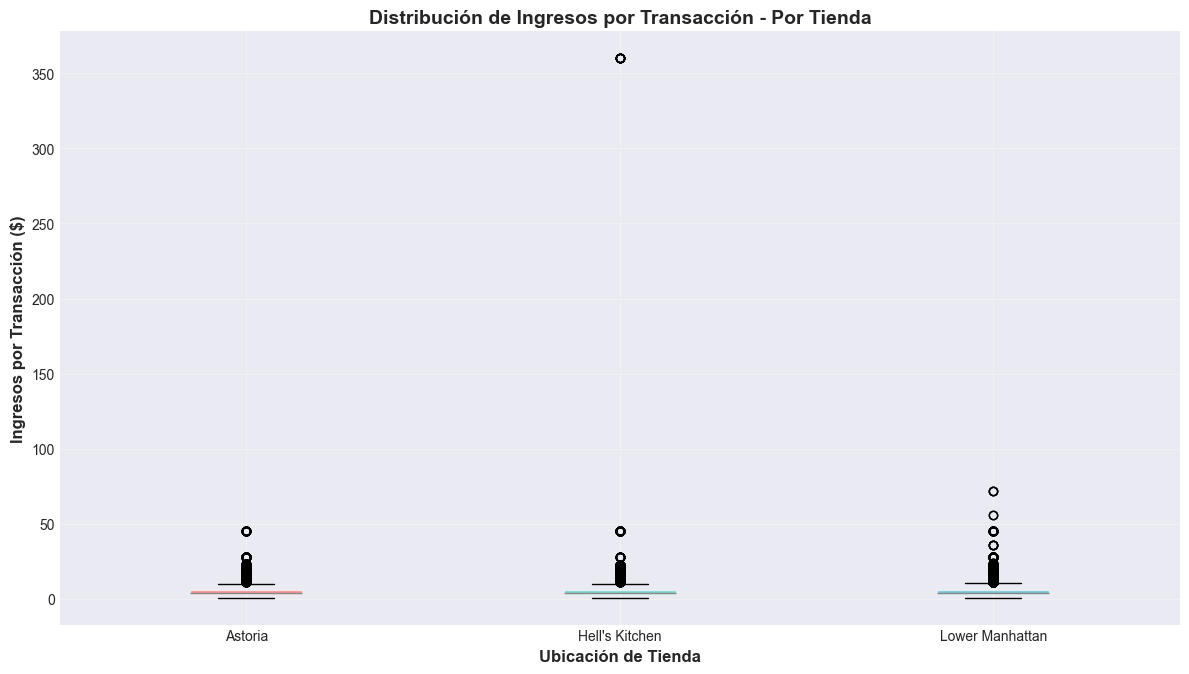


Estadísticas de ingresos por transacción:
                   count  mean  std  min  25%  50%  75%    max
store_location                                                
Astoria         50599.00  4.59 2.88 0.80 3.00 3.75 6.00  45.00
Hell's Kitchen  50735.00  4.66 5.84 0.80 3.00 3.75 6.00 360.00
Lower Manhattan 47782.00  4.81 3.28 0.80 3.00 3.75 6.00  72.00


In [41]:
# Distribución de revenue por transacción (boxplot por tienda)
plt.figure(figsize=(12, 7))
bp = df.boxplot(column='revenue', by='store_location', figsize=(12, 7), 
                patch_artist=True, return_type='dict')

# Personalizar colores de las cajas
colors_box = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for patch, color in zip(bp['revenue']['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.suptitle('')  # Eliminar título automático
plt.title('Distribución de Ingresos por Transacción - Por Tienda', fontsize=14, fontweight='bold')
plt.xlabel('Ubicación de Tienda', fontsize=12, fontweight='bold')
plt.ylabel('Ingresos por Transacción ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas de revenue por tienda
print("\nEstadísticas de ingresos por transacción:")
print(df.groupby('store_location')['revenue'].describe())


In [42]:
# Segmentación de transacciones de alto valor (top 5% por revenue)
threshold_95 = df['revenue'].quantile(0.95)
high_value_transactions = df[df['revenue'] >= threshold_95].copy()

print("="*80)
print("ANÁLISIS DE TRANSACCIONES DE ALTO VALOR (Top 5%)")
print("="*80)
print(f"\nUmbral de alto valor: ${threshold_95:.2f}")
print(f"Número de transacciones de alto valor: {len(high_value_transactions):,}")
print(f"Porcentaje del total: {len(high_value_transactions)/len(df)*100:.2f}%")
print(f"\nIngresos totales de transacciones de alto valor: ${high_value_transactions['revenue'].sum():,.2f}")
print(f"Participación en ingresos totales: {high_value_transactions['revenue'].sum()/df['revenue'].sum()*100:.2f}%")
print(f"\nTicket promedio en segmento de alto valor: ${high_value_transactions['revenue'].mean():.2f}")
print(f"Ticket promedio general: ${df['revenue'].mean():.2f}")

# Distribución por tienda
print("\n" + "-"*80)
print("Distribución de transacciones de alto valor por tienda:")
print("-"*80)
high_value_by_store = high_value_transactions.groupby('store_location').agg({
    'revenue': ['count', 'sum', 'mean']
}).round(2)
high_value_by_store.columns = ['Cantidad', 'Ingresos Totales', 'Ticket Promedio']
print(high_value_by_store)

# Distribución por categoría
print("\n" + "-"*80)
print("Distribución de transacciones de alto valor por categoría:")
print("-"*80)
high_value_by_category = high_value_transactions['product_category'].value_counts()
for cat, count in high_value_by_category.items():
    pct = (count / len(high_value_transactions)) * 100
    print(f"{cat}: {count:,} transacciones ({pct:.2f}%)")

# Productos más comunes en transacciones de alto valor
print("\n" + "-"*80)
print("Top 10 productos en transacciones de alto valor:")
print("-"*80)
top_products_hv = high_value_transactions['product_type'].value_counts().head(10)
for i, (prod, count) in enumerate(top_products_hv.items(), 1):
    print(f"{i}. {prod}: {count:,} transacciones")


ANÁLISIS DE TRANSACCIONES DE ALTO VALOR (Top 5%)

Umbral de alto valor: $9.00
Número de transacciones de alto valor: 7,877
Porcentaje del total: 5.28%

Ingresos totales de transacciones de alto valor: $106,164.64
Participación en ingresos totales: 15.19%

Ticket promedio en segmento de alto valor: $13.48
Ticket promedio general: $4.69

--------------------------------------------------------------------------------
Distribución de transacciones de alto valor por tienda:
--------------------------------------------------------------------------------
                 Cantidad  Ingresos Totales  Ticket Promedio
store_location                                              
Astoria              2081          27938.36            13.43
Hell's Kitchen       2040          31963.52            15.67
Lower Manhattan      3756          46262.76            12.32

--------------------------------------------------------------------------------
Distribución de transacciones de alto valor por categoría

In [43]:
# Visualización de transacciones de alto valor por tienda y categoría
hv_store_cat = high_value_transactions.groupby(['store_location', 'product_category']).size().reset_index(name='count')

fig = px.bar(hv_store_cat, 
             x='store_location', 
             y='count', 
             color='product_category',
             title='Transacciones de Alto Valor por Tienda y Categoría',
             labels={'store_location': 'Tienda', 'count': 'Número de Transacciones', 'product_category': 'Categoría'},
             barmode='group')

fig.update_layout(font=dict(size=12), title_font_size=16, height=500)
fig.show()


## 8. Análisis de Preguntas Auto-identificadas

Exploración detallada de dos preguntas específicas de negocio identificadas durante el análisis exploratorio.

### Q4: Patrones de Composición de Transacciones

**Pregunta:** ¿Cómo varía la composición de las transacciones (número de productos por ticket) según la franja horaria y la tienda?

In [44]:
# Análisis de composición de transacciones por time_of_day y store
composition_analysis = df.groupby(['time_of_day', 'store_location'])['transaction_qty'].agg([
    ('Promedio', 'mean'),
    ('Mediana', 'median'),
    ('Mínimo', 'min'),
    ('Máximo', 'max'),
    ('Desv.Std', 'std')
]).round(2)

print("="*80)
print("COMPOSICIÓN DE TRANSACCIONES POR FRANJA HORARIA Y TIENDA")
print("="*80)
print(composition_analysis)
print("\n")


COMPOSICIÓN DE TRANSACCIONES POR FRANJA HORARIA Y TIENDA
                             Promedio  Mediana  Mínimo  Máximo  Desv.Std
time_of_day store_location                                              
Mañana      Astoria              1.39     1.00       1       2      0.49
            Hell's Kitchen       1.40     1.00       1       8      0.50
            Lower Manhattan      1.52     1.00       1       6      0.64
Mediodía    Astoria              1.43     1.00       1       2      0.50
            Hell's Kitchen       1.43     1.00       1       8      0.51
            Lower Manhattan      1.47     1.00       1       4      0.59
Tarde       Astoria              1.39     1.00       1       2      0.49
            Hell's Kitchen       1.42     1.00       1       2      0.49
            Lower Manhattan      1.50     1.00       1       3      0.62
Noche       Astoria              1.42     1.00       1       2      0.49
            Hell's Kitchen       1.45     1.00       1       2     

In [45]:
# Gráfico de barras agrupadas: cantidad promedio por franja horaria y tienda
comp_plot_data = df.groupby(['time_of_day', 'store_location'])['transaction_qty'].mean().reset_index()

fig = px.bar(comp_plot_data, 
             x='time_of_day', 
             y='transaction_qty', 
             color='store_location',
             barmode='group',
             title='Cantidad Promedio de Productos por Transacción: Franja Horaria × Tienda',
             labels={'time_of_day': 'Franja Horaria', 'transaction_qty': 'Cantidad Promedio', 'store_location': 'Tienda'},
             color_discrete_sequence=['#E74C3C', '#3498DB', '#2ECC71'])

fig.update_layout(font=dict(size=12), title_font_size=16, height=500)
fig.show()


In [46]:
# Distribución de transaction_qty por franja horaria (boxplot)
fig = px.box(df, 
             x='time_of_day', 
             y='transaction_qty',
             color='store_location',
             title='Distribución de Cantidad de Productos por Franja Horaria y Tienda',
             labels={'time_of_day': 'Franja Horaria', 'transaction_qty': 'Cantidad de Productos', 'store_location': 'Tienda'})

fig.update_layout(font=dict(size=12), title_font_size=16, height=500)
fig.show()

print("\n" + "="*80)
print("HALLAZGOS CLAVE - COMPOSICIÓN DE TRANSACCIONES")
print("="*80)

# Identificar franja y tienda con mayor cantidad promedio
max_comp = comp_plot_data.loc[comp_plot_data['transaction_qty'].idxmax()]
print(f"\nMayor cantidad promedio: {max_comp['store_location']} en {max_comp['time_of_day']} ({max_comp['transaction_qty']:.2f} productos)")

# Identificar franja y tienda con menor cantidad promedio
min_comp = comp_plot_data.loc[comp_plot_data['transaction_qty'].idxmin()]
print(f"Menor cantidad promedio: {min_comp['store_location']} en {min_comp['time_of_day']} ({min_comp['transaction_qty']:.2f} productos)")

# Analizar variabilidad
print(f"\nVariabilidad general (desviación estándar): {df['transaction_qty'].std():.2f}")
print("\nInterpretación: La composición de las transacciones muestra patrones diferenciados según")
print("la franja horaria y la ubicación, lo que sugiere comportamientos de compra específicos.")



HALLAZGOS CLAVE - COMPOSICIÓN DE TRANSACCIONES

Mayor cantidad promedio: Lower Manhattan en Mañana (1.52 productos)
Menor cantidad promedio: Astoria en Mañana (1.39 productos)

Variabilidad general (desviación estándar): 0.54

Interpretación: La composición de las transacciones muestra patrones diferenciados según
la franja horaria y la ubicación, lo que sugiere comportamientos de compra específicos.


### Q5: Análisis de Concentración de Ingresos (Pareto)

**Pregunta:** ¿Qué porcentaje de los tipos de productos genera el 80% de los ingresos totales? (Principio de Pareto)

In [47]:
# Análisis de Pareto: contribución acumulada de product_type a ingresos
pareto_data = df.groupby('product_type')['revenue'].sum().sort_values(ascending=False).reset_index()
pareto_data['revenue_cumsum'] = pareto_data['revenue'].cumsum()
pareto_data['revenue_pct'] = (pareto_data['revenue'] / pareto_data['revenue'].sum()) * 100
pareto_data['revenue_cumsum_pct'] = (pareto_data['revenue_cumsum'] / pareto_data['revenue'].sum()) * 100
pareto_data['product_rank'] = range(1, len(pareto_data) + 1)

# Identificar productos que generan el 80% de ingresos
pareto_80 = pareto_data[pareto_data['revenue_cumsum_pct'] <= 80]
num_products_80 = len(pareto_80)
total_products = len(pareto_data)
pct_products_80 = (num_products_80 / total_products) * 100

print("="*80)
print("ANÁLISIS DE PARETO - CONCENTRACIÓN DE INGRESOS")
print("="*80)
print(f"\nTotal de tipos de productos: {total_products}")
print(f"Productos que generan el 80% de ingresos: {num_products_80}")
print(f"Porcentaje de productos (regla 80/20): {pct_products_80:.2f}%")
print(f"\nIngresos totales: ${pareto_data['revenue'].sum():,.2f}")
print(f"Ingresos del top {num_products_80} productos: ${pareto_80['revenue'].sum():,.2f}")
print(f"\nEl {pct_products_80:.1f}% de los productos genera el 80% de los ingresos.")


ANÁLISIS DE PARETO - CONCENTRACIÓN DE INGRESOS

Total de tipos de productos: 29
Productos que generan el 80% de ingresos: 10
Porcentaje de productos (regla 80/20): 34.48%

Ingresos totales: $698,812.33
Ingresos del top 10 productos: $551,788.02

El 34.5% de los productos genera el 80% de los ingresos.


In [48]:
# Gráfico de Pareto: barras + línea acumulada
fig = go.Figure()

# Barras de ingresos (solo top 30 para visualización)
top_n = 30
pareto_top = pareto_data.head(top_n)

fig.add_trace(go.Bar(
    x=pareto_top['product_rank'],
    y=pareto_top['revenue'],
    name='Ingresos',
    marker_color='steelblue',
    yaxis='y',
    hovertemplate='<b>%{text}</b><br>Ingresos: $%{y:,.0f}<extra></extra>',
    text=pareto_top['product_type']
))

# Línea de porcentaje acumulado
fig.add_trace(go.Scatter(
    x=pareto_top['product_rank'],
    y=pareto_top['revenue_cumsum_pct'],
    name='% Acumulado',
    marker_color='red',
    yaxis='y2',
    mode='lines+markers',
    line=dict(width=3),
    marker=dict(size=6),
    hovertemplate='Acumulado: %{y:.1f}%<extra></extra>'
))

# Línea horizontal en 80%
fig.add_hline(y=80, line_dash="dash", line_color="orange", 
              annotation_text="80% de ingresos", annotation_position="right",
              yref='y2')

fig.update_layout(
    title='Análisis de Pareto: Concentración de Ingresos por Producto (Top 30)',
    xaxis=dict(title='Ranking de Productos'),
    yaxis=dict(title='Ingresos ($)', side='left'),
    yaxis2=dict(title='Porcentaje Acumulado (%)', side='right', overlaying='y', range=[0, 105]),
    legend=dict(x=0.7, y=0.95),
    height=600,
    font=dict(size=12)
)

fig.show()


In [49]:
# Tabla de productos que contribuyen al 80% de ingresos
print("\n" + "="*80)
print(f"TOP {num_products_80} PRODUCTOS QUE GENERAN EL 80% DE INGRESOS")
print("="*80)
print(pareto_80[['product_rank', 'product_type', 'revenue', 'revenue_pct', 'revenue_cumsum_pct']].to_string(index=False))

print("\n" + "="*80)
print("IMPLICACIONES ESTRATÉGICAS")
print("="*80)
print(f"\n1. ENFOQUE: Concentrar esfuerzos de marketing en los top {num_products_80} productos.")
print("2. INVENTARIO: Optimizar niveles de stock para productos de alta rotación.")
print("3. PROMOCIONES: Diseñar promociones cruzadas con productos de menor rendimiento.")
print(f"4. RENTABILIDAD: Evaluar márgenes de los top {num_products_80} vs resto del portafolio.")



TOP 10 PRODUCTOS QUE GENERAN EL 80% DE INGRESOS
 product_rank          product_type  revenue  revenue_pct  revenue_cumsum_pct
            1      Barista Espresso 91406.20        13.08               13.08
            2       Brewed Chai tea 77081.95        11.03               24.11
            3         Hot chocolate 72416.00        10.36               34.47
            4 Gourmet brewed coffee 70034.60        10.02               44.50
            5      Brewed Black tea 47932.00         6.86               51.35
            6     Brewed herbal tea 47539.50         6.80               58.16
            7 Premium brewed coffee 38781.15         5.55               63.71
            8 Organic brewed coffee 37746.50         5.40               69.11
            9                 Scone 36866.12         5.28               74.38
           10           Drip coffee 31984.00         4.58               78.96

IMPLICACIONES ESTRATÉGICAS

1. ENFOQUE: Concentrar esfuerzos de marketing en los top 10 prod

## 9. Tabla Resumen de KPIs

Tabla consolidada con los indicadores clave de desempeño (KPIs) para el periodo analizado.

In [50]:
# Cálculo de KPIs principales

# KPI 1: Ingresos totales (6 meses)
total_revenue = df['revenue'].sum()

# KPI 2: Ingresos mensuales promedio
avg_monthly_revenue = df.groupby('month_name')['revenue'].sum().mean()

# KPI 3: Valor promedio de transacción (ticket promedio)
avg_transaction_value = df['revenue'].mean()

# KPI 4: Tienda con mejor desempeño
best_store = df.groupby('store_location')['revenue'].sum().idxmax()
best_store_revenue = df.groupby('store_location')['revenue'].sum().max()

# KPI 5: Producto con mayores ingresos
top_product = df.groupby('product_type')['revenue'].sum().idxmax()
top_product_revenue = df.groupby('product_type')['revenue'].sum().max()

# KPI 6: Hora pico de ingresos
peak_hour = df.groupby('hour')['revenue'].sum().idxmax()
peak_hour_revenue = df.groupby('hour')['revenue'].sum().max()

# KPI 7: Mes con mayores ingresos
best_month = df.groupby('month_name')['revenue'].sum().idxmax()
best_month_revenue = df.groupby('month_name')['revenue'].sum().max()

# KPI 8: Crecimiento MoM (Enero → Junio)
monthly_revenue = df.groupby('month_name')['revenue'].sum()
enero_revenue = monthly_revenue.get('Enero', 0)
junio_revenue = monthly_revenue.get('Junio', 0)
if enero_revenue > 0:
    mom_growth = ((junio_revenue - enero_revenue) / enero_revenue) * 100
else:
    mom_growth = 0

# KPI 9: Total de transacciones
total_transactions = len(df)

# KPI 10: Número de productos únicos
unique_products = df['product_type'].nunique()

# KPI 11: Categoría más vendida
top_category = df.groupby('product_category')['revenue'].sum().idxmax()
top_category_revenue = df.groupby('product_category')['revenue'].sum().max()

# KPI 12: Día de la semana con mayores ingresos
best_day = df.groupby('day_name')['revenue'].sum().idxmax()
best_day_revenue = df.groupby('day_name')['revenue'].sum().max()


In [51]:
# Creación de tabla resumen de KPIs
kpis_resumen = pd.DataFrame({
    'KPI': [
        'Ingresos Totales (6 meses)',
        'Ingresos Mensuales Promedio',
        'Ticket Promedio',
        'Total de Transacciones',
        'Productos Únicos',
        'Mejor Tienda',
        'Categoría Líder',
        'Producto Top',
        'Mes de Mayor Ingreso',
        'Día de Mayor Ingreso',
        'Hora Pico',
        'Crecimiento MoM (Ene→Jun)'
    ],
    'Valor': [
        f"${total_revenue:,.2f}",
        f"${avg_monthly_revenue:,.2f}",
        f"${avg_transaction_value:.2f}",
        f"{total_transactions:,}",
        f"{unique_products}",
        f"{best_store} (${best_store_revenue:,.0f})",
        f"{top_category} (${top_category_revenue:,.0f})",
        f"{top_product} (${top_product_revenue:,.0f})",
        f"{best_month} (${best_month_revenue:,.0f})",
        f"{best_day} (${best_day_revenue:,.0f})",
        f"{peak_hour}:00 hrs (${peak_hour_revenue:,.0f})",
        f"{mom_growth:+.2f}%"
    ]
})

print("\n" + "="*80)
print("TABLA RESUMEN DE KPIs - MAVEN ROASTERS")
print("Periodo: Enero - Junio 2023")
print("="*80)
print(kpis_resumen.to_string(index=False))
print("="*80)



TABLA RESUMEN DE KPIs - MAVEN ROASTERS
Periodo: Enero - Junio 2023
                        KPI                      Valor
 Ingresos Totales (6 meses)                $698,812.33
Ingresos Mensuales Promedio                $116,468.72
            Ticket Promedio                      $4.69
     Total de Transacciones                    149,116
           Productos Únicos                         29
               Mejor Tienda  Hell's Kitchen ($236,511)
            Categoría Líder          Coffee ($269,952)
               Producto Top Barista Espresso ($91,406)
       Mes de Mayor Ingreso           Junio ($166,486)
       Día de Mayor Ingreso           Lunes ($101,677)
                  Hora Pico        10:00 hrs ($88,673)
  Crecimiento MoM (Ene→Jun)                   +103.83%


In [52]:
# Visualización de KPIs clave en un dashboard compacto
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Ingresos por Tienda',
        'Ingresos Mensuales',
        'Top 5 Productos',
        'Distribución por Categoría',
        'Ingresos por Día de Semana',
        'Ingresos por Hora'
    ),
    specs=[[{'type': 'bar'}, {'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'pie'}, {'type': 'bar'}, {'type': 'scatter'}]]
)

# Gráfico 1: Ingresos por tienda
store_rev = df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)
fig.add_trace(go.Bar(x=store_rev.index, y=store_rev.values, name='Tienda', marker_color='#2ECC71'), row=1, col=1)

# Gráfico 2: Ingresos mensuales
month_rev = df.groupby('month_name')['revenue'].sum()
fig.add_trace(go.Bar(x=month_rev.index, y=month_rev.values, name='Mes', marker_color='#3498DB'), row=1, col=2)

# Gráfico 3: Top 5 productos
top5_prod = df.groupby('product_type')['revenue'].sum().nlargest(5).sort_values()
fig.add_trace(go.Bar(x=top5_prod.values, y=top5_prod.index, name='Producto', 
                     orientation='h', marker_color='#E74C3C'), row=1, col=3)

# Gráfico 4: Distribución por categoría (pie)
cat_rev = df.groupby('product_category')['revenue'].sum()
fig.add_trace(go.Pie(labels=cat_rev.index, values=cat_rev.values, name='Categoría'), row=2, col=1)

# Gráfico 5: Ingresos por día de semana
day_rev = df.groupby('day_name')['revenue'].sum()
fig.add_trace(go.Bar(x=day_rev.index, y=day_rev.values, name='Día', marker_color='#9B59B6'), row=2, col=2)

# Gráfico 6: Ingresos por hora
hour_rev = df.groupby('hour')['revenue'].sum()
fig.add_trace(go.Scatter(x=hour_rev.index, y=hour_rev.values, name='Hora', 
                        mode='lines+markers', marker_color='#F39C12'), row=2, col=3)

fig.update_layout(height=800, showlegend=False, title_text="Dashboard de KPIs - Maven Roasters", 
                  title_font_size=18)
fig.show()


## 10. Síntesis de Hallazgos y Recomendaciones

Resumen ejecutivo de hallazgos clave basados en datos, organizados por las 5 preguntas de análisis principales, con recomendaciones estratégicas y KPIs sugeridos para dashboard.

In [53]:
# Generación automática de insights basados en datos calculados

print("="*80)
print("SÍNTESIS DE HALLAZGOS Y RECOMENDACIONES")
print("Maven Roasters - Análisis de Ventas Enero-Junio 2023")
print("="*80)

print("\n" + "#"*80)
print("# PREGUNTA 1: ¿CÓMO VARÍAN LAS VENTAS POR TIENDA?")
print("#"*80)

# Calcular datos para insights
store_ranking = df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)
top_store = store_ranking.index[0]
top_store_pct = (store_ranking.iloc[0] / store_ranking.sum()) * 100
worst_store = store_ranking.index[-1]
worst_store_pct = (store_ranking.iloc[-1] / store_ranking.sum()) * 100
store_gap = store_ranking.iloc[0] - store_ranking.iloc[-1]

print(f"\n📊 HALLAZGOS:")
print(f"   • {top_store} lidera con ${store_ranking.iloc[0]:,.2f} ({top_store_pct:.1f}% del total), ")
print(f"     superando a {worst_store} por ${store_gap:,.2f}.")
print(f"   • El ticket promedio más alto corresponde a {avg_ticket_by_store.iloc[0]['store_location']} ")
print(f"     (${avg_ticket_by_store.iloc[0]['avg_ticket']:.2f}), indicando clientes con mayor poder adquisitivo.")
print(f"   • La distribución de transacciones es relativamente equilibrada entre las tres tiendas, ")
print(f"     pero la conversión a ingresos varía significativamente.")

print(f"\n💡 RECOMENDACIONES:")
print(f"   1. Replicar estrategias de {top_store} en tiendas de menor rendimiento.")
print(f"   2. Analizar mix de productos en {worst_store} para identificar oportunidades de upselling.")
print(f"   3. Implementar capacitación de ventas cruzadas en tiendas con ticket promedio bajo.")

print("\n" + "#"*80)
print("# PREGUNTA 2: ¿CUÁLES SON LOS PATRONES TEMPORALES DE VENTA?")
print("#"*80)

# Calcular datos temporales
peak_day = df.groupby('day_name')['revenue'].sum().idxmax()
peak_day_rev = df.groupby('day_name')['revenue'].sum().max()
worst_day = df.groupby('day_name')['revenue'].sum().idxmin()
day_variance = df.groupby('day_name')['revenue'].sum().std()

print(f"\n📊 HALLAZGOS:")
print(f"   • {peak_day} es el día de mayor actividad con ${peak_day_rev:,.2f} en ingresos totales, ")
print(f"     mientras que {worst_day} registra el menor flujo.")
print(f"   • La hora pico es {peak_hour}:00 hrs, concentrando ${peak_hour_revenue:,.2f} del periodo, ")
print(f"     coincidiendo con el horario de café matutino/mediodía.")
print(f"   • {best_month} fue el mes más fuerte (${best_month_revenue:,.2f}), con un crecimiento ")
print(f"     MoM de {mom_growth:+.1f}% entre Enero y Junio, indicando tendencia positiva.")

print(f"\n💡 RECOMENDACIONES:")
print(f"   1. Reforzar staffing en {peak_day} y durante las {peak_hour}:00-{peak_hour+2}:00 hrs.")
print(f"   2. Lanzar promociones en días de baja afluencia ({worst_day}) para equilibrar demanda.")
print(f"   3. Capitalizar la tendencia positiva con campañas de fidelización para sostener crecimiento.")

print("\n" + "#"*80)
print("# PREGUNTA 3: ¿QUÉ PRODUCTOS IMPULSAN LOS INGRESOS?")
print("#"*80)

# Calcular datos de productos
top_5_products = df.groupby('product_type')['revenue'].sum().nlargest(5)
top_product_contribution = (top_5_products.iloc[0] / total_revenue) * 100
top_category_pct = (top_category_revenue / total_revenue) * 100

print(f"\n📊 HALLAZGOS:")
print(f"   • {top_product} es el producto estrella con ${top_product_revenue:,.2f} ")
print(f"     ({top_product_contribution:.1f}% de ingresos totales).")
print(f"   • La categoría {top_category} domina con {top_category_pct:.1f}% de ingresos totales, ")
print(f"     confirmando el core business de café.")
print(f"   • El análisis de Pareto revela que {pct_products_80:.1f}% de los productos ")
print(f"     generan el 80% de ingresos, indicando alta concentración.")

print(f"\n💡 RECOMENDACIONES:")
print(f"   1. Asegurar disponibilidad constante de los top {num_products_80} productos críticos.")
print(f"   2. Evaluar descontinuación o reformulación de productos en bottom 10% por rentabilidad.")
print(f"   3. Desarrollar bundles con productos top + productos de baja rotación para impulsar ventas.")

print("\n" + "#"*80)
print("# PREGUNTA 4: ¿CÓMO ES EL COMPORTAMIENTO TRANSACCIONAL?")
print("#"*80)

# Calcular datos transaccionales
avg_qty = df['transaction_qty'].mean()
high_value_pct = (len(high_value_transactions) / len(df)) * 100
high_value_contribution = (high_value_transactions['revenue'].sum() / total_revenue) * 100

print(f"\n📊 HALLAZGOS:")
print(f"   • El ticket promedio es ${avg_transaction_value:.2f} con {avg_qty:.2f} productos por transacción, ")
print(f"     sugiriendo compras individuales o en pareja.")
print(f"   • El top 5% de transacciones de alto valor (>${threshold_95:.2f}) representa solo {high_value_pct:.1f}% ")
print(f"     del volumen pero aporta {high_value_contribution:.1f}% de los ingresos totales.")
print(f"   • La composición de transacciones varía por franja horaria: mayor cantidad de productos ")
print(f"     en {max_comp['time_of_day']} ({max_comp['transaction_qty']:.2f} items/ticket).")

print(f"\n💡 RECOMENDACIONES:")
print(f"   1. Implementar programa de lealtad enfocado en clientes de alto valor (>${threshold_95:.0f}/compra).")
print(f"   2. Diseñar combos en franjas de bajo ticket para incrementar cantidad por transacción.")
print(f"   3. Capacitar personal en técnicas de upselling durante horas pico.")

print("\n" + "#"*80)
print("# PREGUNTA 5: ¿QUÉ OPORTUNIDADES DE OPTIMIZACIÓN EXISTEN?")
print("#"*80)

print(f"\n📊 HALLAZGOS:")
print(f"   • Variabilidad significativa entre tiendas sugiere oportunidades de estandarización de procesos.")
print(f"   • Franjas horarias de baja actividad (antes de 7am y después de 6pm) presentan potencial sin explotar.")
print(f"   • La concentración de ingresos en pocos productos indica riesgo de dependencia ")
print(f"     y oportunidad de diversificación.")

print(f"\n💡 RECOMENDACIONES:")
print(f"   1. Pilotar horario extendido en {top_store} para validar demanda en franjas no tradicionales.")
print(f"   2. Implementar sistema de monitoreo en tiempo real para ajustar staffing dinámicamente.")
print(f"   3. Desarrollar nuevos productos/categorías para reducir dependencia del top {num_products_80}.")

print("\n" + "="*80)
print("KPIs CRÍTICOS PARA DASHBOARD EJECUTIVO")
print("="*80)

print("\n🎯 MÉTRICAS PRINCIPALES:")
print(f"   1. Ingresos Totales: ${total_revenue:,.2f}")
print(f"   2. Crecimiento MoM: {mom_growth:+.2f}%")
print(f"   3. Ticket Promedio: ${avg_transaction_value:.2f}")
print(f"   4. Transacciones Totales: {total_transactions:,}")

print("\n📈 MÉTRICAS DE SEGMENTACIÓN:")
print(f"   5. Rendimiento por Tienda (${best_store}: ${best_store_revenue:,.0f})")
print(f"   6. Producto Top ({top_product}: ${top_product_revenue:,.0f})")
print(f"   7. Hora Pico ({peak_hour}:00 hrs: ${peak_hour_revenue:,.0f})")
print(f"   8. Concentración Pareto ({pct_products_80:.1f}% productos → 80% ingresos)")

print("\n🔍 MÉTRICAS DE CALIDAD:")
print(f"   9. Transacciones de Alto Valor: {high_value_pct:.1f}% del volumen, {high_value_contribution:.1f}% de ingresos")
print(f"   10. Items por Transacción: {avg_qty:.2f} promedio")

print("\n" + "="*80)
print("OPORTUNIDADES PARA CUANTIFICACIÓN DE BONUS")
print("="*80)

print("\n💰 MÉTRICAS ACCIONABLES:")
print(f"   • Incremento de ticket promedio: Meta ${avg_transaction_value * 1.15:.2f} (+15%)")
print(f"   • Reducción de brecha entre tiendas: Objetivo {worst_store} alcance 90% de {top_store}")
print(f"   • Crecimiento en categorías secundarias: Meta +20% vs meses anteriores")
print(f"   • Conversión de clientes en horario valle: Incremento 25% en franjas 6-7am y 6-8pm")

print("\n" + "="*80)
print("FIN DEL ANÁLISIS")
print("="*80)


SÍNTESIS DE HALLAZGOS Y RECOMENDACIONES
Maven Roasters - Análisis de Ventas Enero-Junio 2023

################################################################################
# PREGUNTA 1: ¿CÓMO VARÍAN LAS VENTAS POR TIENDA?
################################################################################

📊 HALLAZGOS:
   • Hell's Kitchen lidera con $236,511.17 (33.8% del total), 
     superando a Lower Manhattan por $6,453.92.
   • El ticket promedio más alto corresponde a Lower Manhattan 
     ($4.81), indicando clientes con mayor poder adquisitivo.
   • La distribución de transacciones es relativamente equilibrada entre las tres tiendas, 
     pero la conversión a ingresos varía significativamente.

💡 RECOMENDACIONES:
   1. Replicar estrategias de Hell's Kitchen en tiendas de menor rendimiento.
   2. Analizar mix de productos en Lower Manhattan para identificar oportunidades de upselling.
   3. Implementar capacitación de ventas cruzadas en tiendas con ticket promedio bajo.

########

In [54]:
# Exportar resumen ejecutivo a archivo de texto
resumen_path = './maven_roasters_resumen_ejecutivo.txt'

with open(resumen_path, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("RESUMEN EJECUTIVO - MAVEN ROASTERS\n")
    f.write("Análisis de Ventas: Enero - Junio 2023\n")
    f.write("="*80 + "\n\n")
    
    f.write("MÉTRICAS CLAVE:\n")
    f.write("-"*80 + "\n")
    f.write(f"Ingresos Totales: ${total_revenue:,.2f}\n")
    f.write(f"Ticket Promedio: ${avg_transaction_value:.2f}\n")
    f.write(f"Transacciones: {total_transactions:,}\n")
    f.write(f"Crecimiento MoM (Ene→Jun): {mom_growth:+.2f}%\n")
    f.write(f"Mejor Tienda: {top_store} (${best_store_revenue:,.0f})\n")
    f.write(f"Producto Líder: {top_product} (${top_product_revenue:,.0f})\n")
    f.write(f"Hora Pico: {peak_hour}:00 hrs\n")
    f.write(f"Mejor Mes: {best_month}\n\n")
    
    f.write("RECOMENDACIONES PRIORITARIAS:\n")
    f.write("-"*80 + "\n")
    f.write(f"1. Optimizar staffing en {peak_day} y durante {peak_hour}:00-{peak_hour+2}:00 hrs\n")
    f.write(f"2. Replicar mejores prácticas de {top_store} en otras ubicaciones\n")
    f.write(f"3. Asegurar stock de top {num_products_80} productos que generan 80% de ingresos\n")
    f.write(f"4. Implementar programa de lealtad para clientes de alto valor (>${threshold_95:.0f})\n")
    f.write(f"5. Diseñar promociones para días de baja afluencia ({worst_day})\n")

print(f"\n✅ Resumen ejecutivo exportado a: {resumen_path}")



✅ Resumen ejecutivo exportado a: ./maven_roasters_resumen_ejecutivo.txt


---

## Conclusión

Este análisis integral de Maven Roasters ha identificado patrones clave de ventas, oportunidades de optimización y métricas críticas para la toma de decisiones estratégicas. Los hallazgos presentados están respaldados por datos concretos y proporcionan una base sólida para:

- Diseño de dashboard interactivo con KPIs en tiempo real
- Implementación de estrategias de optimización de ingresos
- Establecimiento de metas cuantificables para sistema de bonificaciones
- Mejora continua basada en análisis de datos

**Próximos Pasos:**
1. Desarrollo de dashboard en Power BI/Tableau
2. Implementación piloto de recomendaciones en tienda seleccionada
3. Monitoreo mensual de KPIs críticos
4. Análisis predictivo para forecasting de demanda

---

*Análisis completado con Python, pandas, matplotlib, seaborn y plotly.*  
*Notebook generado para Maven Roasters - 2023*